In [81]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

In [82]:
df = pd.read_excel('df_selected.xlsx')
df_valid = df.copy()
df_valid['Ordered'] = pd.to_datetime(df_valid['Ordered'])
df_valid['hour'] = df_valid['Ordered'].dt.hour
df_valid['arrival_day'] = df_valid['Ordered'].dt.floor('D')

df_no_weekend = df_valid[df_valid['arrival_day'].dt.weekday < 5].copy()

In [83]:
df_no_weekend['Procedure_duration_hours'] = (
    (df_no_weekend['ScanStopF'] - df_no_weekend['ScanStartF']).dt.total_seconds() / 3600
)

df_no_weekend = df_no_weekend[df_no_weekend['Procedure_duration_hours'] < 6].copy()

# Proceudre Service Time

In [106]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt


def fit_service_time_distribution(
    df,
    duration_col,
    class_col=None,
    max_hours=6,
    min_positive=True,
    bins=30,
    alpha=0.05,
    show_plots=True
):
    """
    Fit service-time distributions to a duration column in hours.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    duration_col : str
        Column containing service duration in hours.
    class_col : str or None
        Optional classification column. If given, fit separately by class.
    max_hours : float or None
        Drop durations greater than this threshold. If None, keep all.
    min_positive : bool
        If True, keep only durations > 0.
    bins : int
        Number of histogram bins.
    alpha : float
        Significance level for KS test.
    show_plots : bool
        Whether to show histogram, fitted curves, and Q-Q plots.

    Returns
    -------
    results_df : pandas.DataFrame
        Summary of fitted results.
    cleaned_df : pandas.DataFrame
        Cleaned dataframe used for fitting.
    outliers_df : pandas.DataFrame
        Outliers removed because duration > max_hours.
    """

    df_work = df.copy()

    # keep outliers separately
    if max_hours is not None:
        outliers_df = df_work[df_work[duration_col] > max_hours].copy()
    else:
        outliers_df = df_work.iloc[0:0].copy()

    # cleaning
    mask = df_work[duration_col].notna()

    if min_positive:
        mask &= df_work[duration_col] > 0

    if max_hours is not None:
        mask &= df_work[duration_col] <= max_hours

    df_work = df_work.loc[mask].copy()

    print(f"Number kept: {len(df_work)}")
    print(f"Number dropped as outliers: {len(outliers_df)}")

    # decide grouping
    if class_col is None:
        groups = [('All', df_work)]
    else:
        groups = list(df_work.groupby(class_col))

    all_results = []

    for group_name, group_df in groups:
        service_data = group_df[duration_col].dropna().astype(float)

        if len(service_data) < 5:
            print(f"\n{group_name}: not enough data to fit.")
            continue

        print("\n" + "=" * 90)
        print(f"Group: {group_name}")
        print(f"n = {len(service_data)}")
        print(f"Mean duration (hours): {service_data.mean():.4f}")
        print(f"Std duration (hours): {service_data.std():.4f}")
        print(f"Min duration (hours): {service_data.min():.4f}")
        print(f"Max duration (hours): {service_data.max():.4f}")

        mean_service_time = service_data.mean()
        mu = 1 / mean_service_time
        print(f"Average service rate (patients/hour): {mu:.4f}")

        # fit distributions
        exp_loc, exp_scale = stats.expon.fit(service_data, floc=0)
        exp_params = (exp_loc, exp_scale)

        gamma_a, gamma_loc, gamma_scale = stats.gamma.fit(service_data, floc=0)
        gamma_params = (gamma_a, gamma_loc, gamma_scale)

        weibull_c, weibull_loc, weibull_scale = stats.weibull_min.fit(service_data, floc=0)
        weibull_params = (weibull_c, weibull_loc, weibull_scale)

        lognorm_sigma, lognorm_loc, lognorm_scale = stats.lognorm.fit(service_data, floc=0)
        lognorm_params = (lognorm_sigma, lognorm_loc, lognorm_scale)

        # KS tests
        ks_results = []

        for dist_name, scipy_name, params in [
            ('Exponential', 'expon', exp_params),
            ('Gamma', 'gamma', gamma_params),
            ('Weibull', 'weibull_min', weibull_params),
            ('Lognormal', 'lognorm', lognorm_params)
        ]:
            D, p_value = stats.kstest(service_data, scipy_name, args=params)
            decision = "Fail to reject" if p_value >= alpha else "Reject"

            ks_results.append({
                'group': group_name,
                'distribution': dist_name,
                'KS_D': D,
                'KS_p_value': p_value,
                'decision': decision
            })

        ks_df = pd.DataFrame(ks_results).sort_values(['KS_D', 'KS_p_value'], ascending=[True, False])

        print("\nKS test results:")
        print(ks_df[['distribution', 'KS_D', 'KS_p_value', 'decision']])

        # plots
        if show_plots:
            # histogram
            plt.figure(figsize=(10, 6))
            plt.hist(service_data, bins=bins, density=True, alpha=0.6)
            plt.title(f'Histogram of Service Duration (Hours) - {group_name}')
            plt.xlabel('Service Duration (Hours)')
            plt.ylabel('Density')
            plt.show()

            # fitted curves
            plt.figure(figsize=(12, 8))
            plt.hist(service_data, bins=bins, density=True, alpha=0.5, label='Data')

            x = np.linspace(service_data.min(), service_data.max(), 300)
            plt.plot(x, stats.expon.pdf(x, *exp_params), label='Exponential')
            plt.plot(x, stats.gamma.pdf(x, *gamma_params), label='Gamma')
            plt.plot(x, stats.weibull_min.pdf(x, *weibull_params), label='Weibull')
            plt.plot(x, stats.lognorm.pdf(x, *lognorm_params), label='Lognormal')

            plt.title(f'Service Duration (Hours) with Fitted Distributions - {group_name}')
            plt.xlabel('Service Duration (Hours)')
            plt.ylabel('Density')
            plt.legend()
            plt.show()

            # QQ plots
            fig, axs = plt.subplots(1, 4, figsize=(24, 6))

            sorted_data = np.sort(service_data)
            prob = (np.arange(1, len(service_data) + 1) - 0.5) / len(service_data)

            theoretical_exp = stats.expon.ppf(prob, *exp_params)
            axs[0].plot(theoretical_exp, sorted_data, 'o', markersize=4)
            axs[0].plot(theoretical_exp, theoretical_exp, 'r--')
            axs[0].set_title(f"Q-Q Plot: Exponential\n{group_name}")

            theoretical_gamma = stats.gamma.ppf(prob, *gamma_params)
            axs[1].plot(theoretical_gamma, sorted_data, 'o', markersize=4)
            axs[1].plot(theoretical_gamma, theoretical_gamma, 'r--')
            axs[1].set_title(f"Q-Q Plot: Gamma\n{group_name}")

            theoretical_weibull = stats.weibull_min.ppf(prob, *weibull_params)
            axs[2].plot(theoretical_weibull, sorted_data, 'o', markersize=4)
            axs[2].plot(theoretical_weibull, theoretical_weibull, 'r--')
            axs[2].set_title(f"Q-Q Plot: Weibull\n{group_name}")

            theoretical_lognorm = stats.lognorm.ppf(prob, *lognorm_params)
            axs[3].plot(theoretical_lognorm, sorted_data, 'o', markersize=4)
            axs[3].plot(theoretical_lognorm, theoretical_lognorm, 'r--')
            axs[3].set_title(f"Q-Q Plot: Lognormal\n{group_name}")

            for ax in axs:
                ax.set_xlabel("Theoretical Quantiles")
                ax.set_ylabel("Empirical Quantiles")

            plt.tight_layout()
            plt.show()

        best_row = ks_df.iloc[0].copy()

        best_row['n'] = len(service_data)
        best_row['mean_duration_hours'] = mean_service_time
        best_row['service_rate_per_hour'] = mu

        if best_row['distribution'] == 'Exponential':
            best_row['param_1_name'] = 'loc'
            best_row['param_1_value'] = exp_loc
            best_row['param_2_name'] = 'scale'
            best_row['param_2_value'] = exp_scale

        elif best_row['distribution'] == 'Gamma':
            best_row['param_1_name'] = 'shape'
            best_row['param_1_value'] = gamma_a
            best_row['param_2_name'] = 'loc'
            best_row['param_2_value'] = gamma_loc
            best_row['param_3_name'] = 'scale'
            best_row['param_3_value'] = gamma_scale

        elif best_row['distribution'] == 'Weibull':
            best_row['param_1_name'] = 'shape'
            best_row['param_1_value'] = weibull_c
            best_row['param_2_name'] = 'loc'
            best_row['param_2_value'] = weibull_loc
            best_row['param_3_name'] = 'scale'
            best_row['param_3_value'] = weibull_scale

        elif best_row['distribution'] == 'Lognormal':
            best_row['param_1_name'] = 'sigma'
            best_row['param_1_value'] = lognorm_sigma
            best_row['param_2_name'] = 'loc'
            best_row['param_2_value'] = lognorm_loc
            best_row['param_3_name'] = 'scale'
            best_row['param_3_value'] = lognorm_scale

        all_results.append(best_row)


    results_df = pd.DataFrame(all_results)
    return results_df, df_work, outliers_df

Number kept: 2346
Number dropped as outliers: 0

Group: All
n = 2346
Mean duration (hours): 1.2951
Std duration (hours): 0.7863
Min duration (hours): 0.0167
Max duration (hours): 5.0833
Average service rate (patients/hour): 0.7721

KS test results:
  distribution      KS_D    KS_p_value        decision
1        Gamma  0.026386  7.491954e-02  Fail to reject
2      Weibull  0.032295  1.465880e-02          Reject
3    Lognormal  0.061517  3.681718e-08          Reject
0  Exponential  0.198367  2.247904e-81          Reject


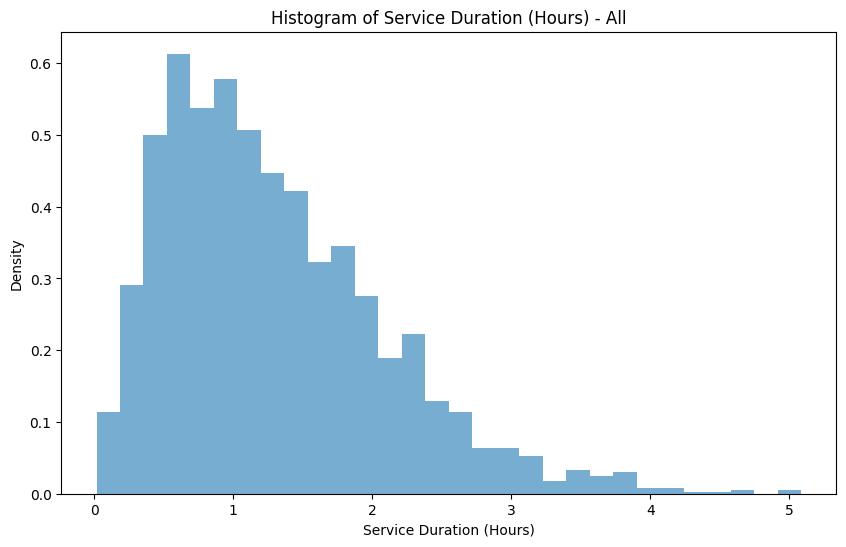

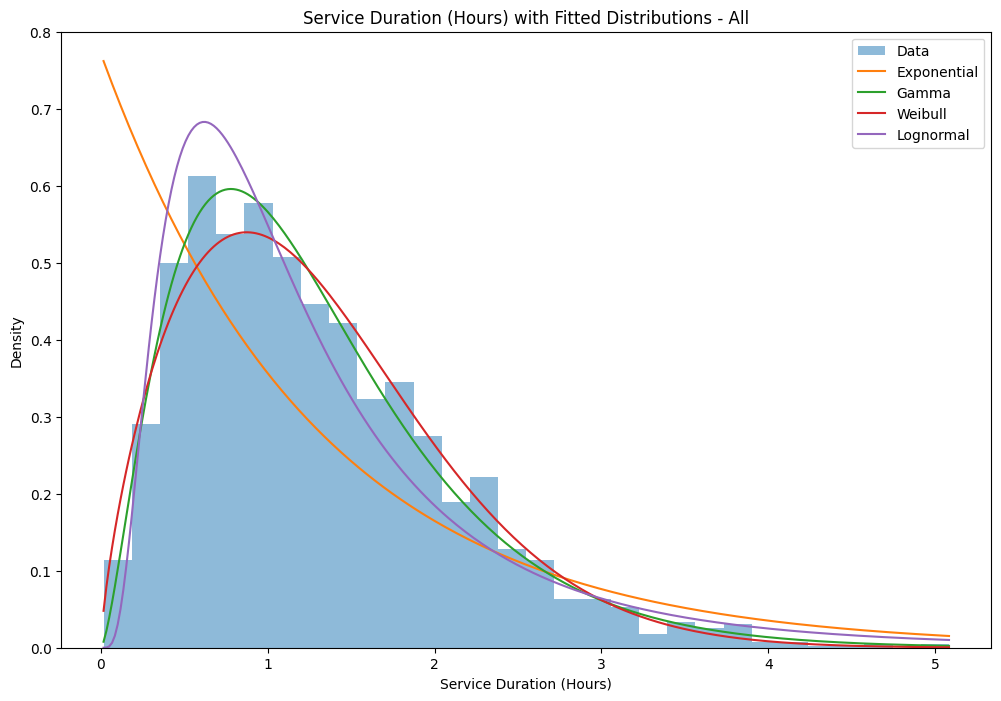

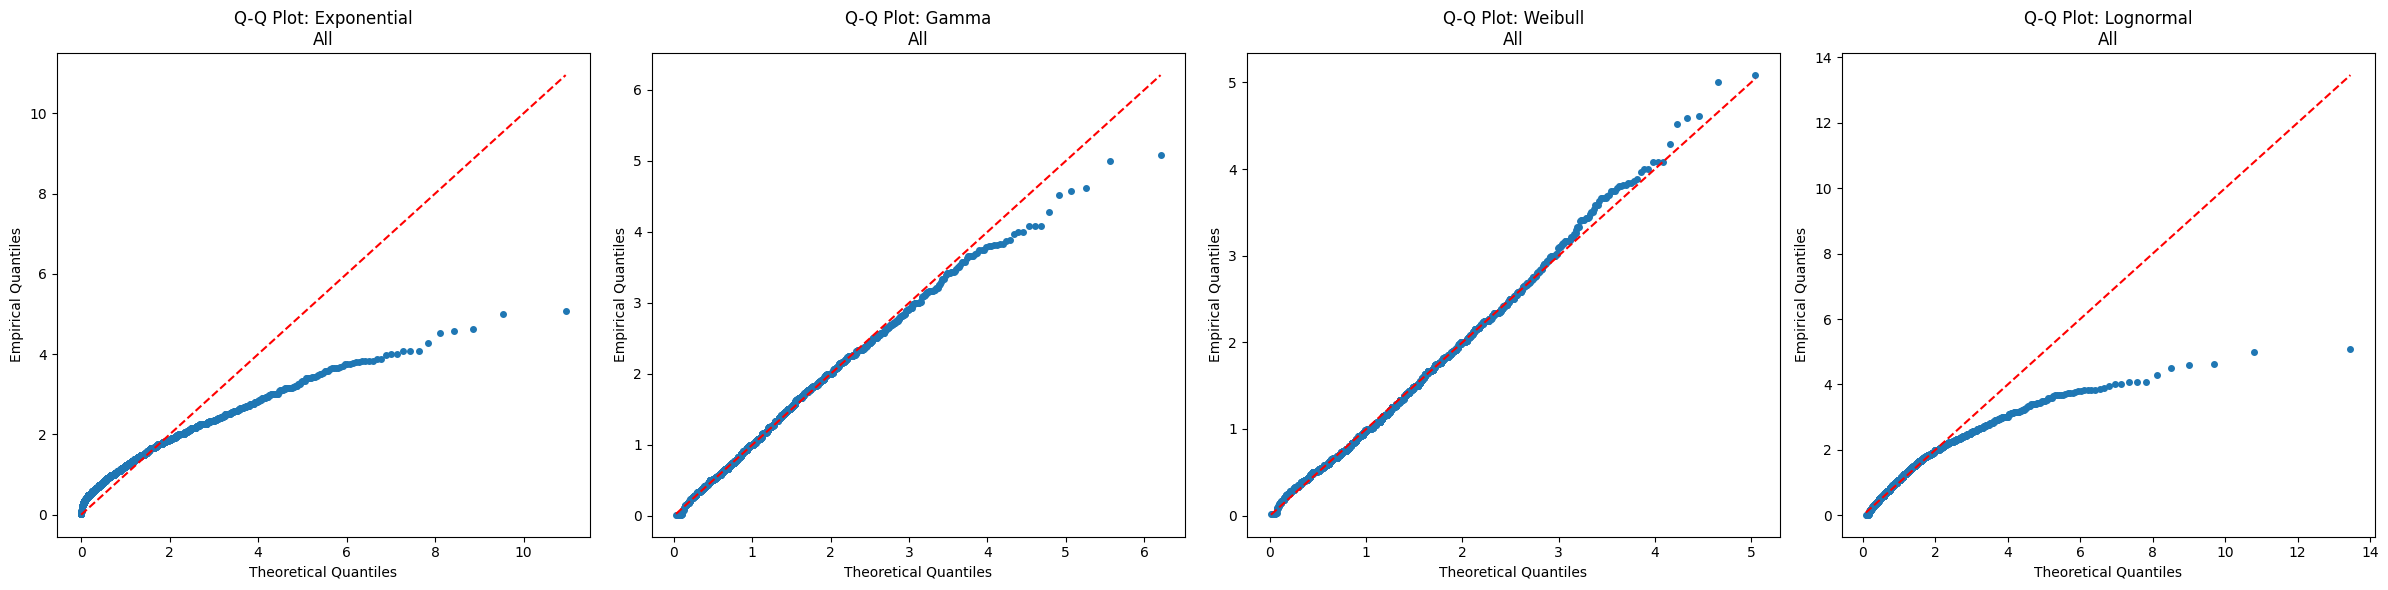

  group distribution      KS_D  KS_p_value        decision     n  \
1   All        Gamma  0.026386     0.07492  Fail to reject  2346   

   mean_duration_hours  service_rate_per_hour param_1_name  param_1_value  \
1             1.295105               0.772138        shape       2.513292   

  param_2_name  param_2_value param_3_name  param_3_value  
1          loc              0        scale       0.515302  


In [107]:
results_df, cleaned_df, outliers_df = fit_service_time_distribution(
    df=df_no_weekend,
    duration_col='Procedure_duration_hours',
    class_col=None,
    max_hours=180,
    alpha=0.05,
    show_plots=True
)

print(results_df)

# Preparation

In [112]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt


def fit_service_time_distribution(
    df,
    duration_col,
    group_cols=None,
    max_days=None,
    min_positive=True,
    bins=30,
    alpha=0.05,
    show_plots=True
):
    """
    Fit candidate distributions to a duration column, optionally by multiple groups.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    duration_col : str
        Column containing duration values.
    group_cols : str or list[str] or None
        Column(s) used for grouping. If None, fit on all data together.
    max_days : float or None
        Drop durations greater than this threshold. If None, keep all.
    min_positive : bool
        If True, keep only durations > 0.
    bins : int
        Number of histogram bins.
    alpha : float
        Significance level for KS test.
    show_plots : bool
        Whether to show plots.

    Returns
    -------
    best_results_df : pandas.DataFrame
        Best-fitting distribution for each group.
    all_results_df : pandas.DataFrame
        KS results for all fitted distributions for all groups.
    cleaned_df : pandas.DataFrame
        Cleaned dataframe used for fitting.
    outliers_df : pandas.DataFrame
        Rows removed because duration > max_days.
    fit_params_dict : dict
        Nested dictionary of fitted parameters for each group and distribution.
    """

    df_work = df.copy()

    if max_days is not None:
        outliers_df = df_work[df_work[duration_col] > max_days].copy()
    else:
        outliers_df = df_work.iloc[0:0].copy()

    mask = df_work[duration_col].notna()

    if min_positive:
        mask &= df_work[duration_col] > 0

    if max_days is not None:
        mask &= df_work[duration_col] <= max_days

    df_work = df_work.loc[mask].copy()

    print(f"Number kept: {len(df_work)}")
    print(f"Number dropped as outliers: {len(outliers_df)}")

    if group_cols is None:
        groups = [("All", df_work)]
        group_cols = []
    else:
        if isinstance(group_cols, str):
            group_cols = [group_cols]
        groups = list(df_work.groupby(group_cols, dropna=False))

    best_results = []
    all_results = []
    fit_params_dict = {}

    for group_name, group_df in groups:
        if not isinstance(group_name, tuple):
            group_name = (group_name,)

        group_key = " | ".join(
            f"{col}={val}" for col, val in zip(group_cols, group_name)
        ) if group_cols else "All"

        service_data = group_df[duration_col].dropna().astype(float)

        if len(service_data) < 5:
            print(f"\n{group_key}: not enough data to fit.")
            continue

        print("\n" + "=" * 90)
        print(f"Group: {group_key}")
        print(f"n = {len(service_data)}")
        print(f"Mean duration: {service_data.mean():.4f}")
        print(f"Std duration: {service_data.std():.4f}")
        print(f"Min duration: {service_data.min():.4f}")
        print(f"Max duration: {service_data.max():.4f}")

        mean_service_time = service_data.mean()
        service_rate = 1 / mean_service_time
        print(f"Average service rate: {service_rate:.4f}")

        exp_loc, exp_scale = stats.expon.fit(service_data, floc=0)
        exp_params = (exp_loc, exp_scale)

        gamma_a, gamma_loc, gamma_scale = stats.gamma.fit(service_data, floc=0)
        gamma_params = (gamma_a, gamma_loc, gamma_scale)

        weibull_c, weibull_loc, weibull_scale = stats.weibull_min.fit(service_data, floc=0)
        weibull_params = (weibull_c, weibull_loc, weibull_scale)

        lognorm_sigma, lognorm_loc, lognorm_scale = stats.lognorm.fit(service_data, floc=0)
        lognorm_params = (lognorm_sigma, lognorm_loc, lognorm_scale)

        fit_params_dict[group_key] = {
            "Exponential": {
                "loc": exp_loc,
                "scale": exp_scale,
            },
            "Gamma": {
                "shape": gamma_a,
                "loc": gamma_loc,
                "scale": gamma_scale,
            },
            "Weibull": {
                "shape": weibull_c,
                "loc": weibull_loc,
                "scale": weibull_scale,
            },
            "Lognormal": {
                "sigma": lognorm_sigma,
                "loc": lognorm_loc,
                "scale": lognorm_scale,
            },
        }

        ks_results = []
        dist_specs = [
            ("Exponential", "expon", exp_params),
            ("Gamma", "gamma", gamma_params),
            ("Weibull", "weibull_min", weibull_params),
            ("Lognormal", "lognorm", lognorm_params),
        ]

        for dist_name, scipy_name, params in dist_specs:
            D, p_value = stats.kstest(service_data, scipy_name, args=params)
            decision = "Fail to reject" if p_value >= alpha else "Reject"

            row = {
                "group": group_key,
                "distribution": dist_name,
                "KS_D": D,
                "KS_p_value": p_value,
                "decision": decision,
                "n": len(service_data),
                "mean_duration": mean_service_time,
                "service_rate": service_rate,
            }

            if dist_name == "Exponential":
                row.update({
                    "param_1_name": "loc",
                    "param_1_value": exp_loc,
                    "param_2_name": "scale",
                    "param_2_value": exp_scale,
                    "param_3_name": None,
                    "param_3_value": None,
                })
            elif dist_name == "Gamma":
                row.update({
                    "param_1_name": "shape",
                    "param_1_value": gamma_a,
                    "param_2_name": "loc",
                    "param_2_value": gamma_loc,
                    "param_3_name": "scale",
                    "param_3_value": gamma_scale,
                })
            elif dist_name == "Weibull":
                row.update({
                    "param_1_name": "shape",
                    "param_1_value": weibull_c,
                    "param_2_name": "loc",
                    "param_2_value": weibull_loc,
                    "param_3_name": "scale",
                    "param_3_value": weibull_scale,
                })
            elif dist_name == "Lognormal":
                row.update({
                    "param_1_name": "sigma",
                    "param_1_value": lognorm_sigma,
                    "param_2_name": "loc",
                    "param_2_value": lognorm_loc,
                    "param_3_name": "scale",
                    "param_3_value": lognorm_scale,
                })

            ks_results.append(row)

        ks_df = pd.DataFrame(ks_results).sort_values(
            ["KS_D", "KS_p_value"], ascending=[True, False]
        )

        print("\nKS test results:")
        print(ks_df[["distribution", "KS_D", "KS_p_value", "decision"]])

        all_results.append(ks_df)
        best_results.append(ks_df.iloc[0].copy())

        if show_plots:
            plt.figure(figsize=(10, 6))
            plt.hist(service_data, bins=bins, density=True, alpha=0.6)
            plt.title(f"Histogram - {group_key}")
            plt.xlabel(duration_col)
            plt.ylabel("Density")
            plt.show()

            plt.figure(figsize=(12, 8))
            plt.hist(service_data, bins=bins, density=True, alpha=0.5, label="Data")

            x = np.linspace(service_data.min(), service_data.max(), 300)
            plt.plot(x, stats.expon.pdf(x, *exp_params), label="Exponential")
            plt.plot(x, stats.gamma.pdf(x, *gamma_params), label="Gamma")
            plt.plot(x, stats.weibull_min.pdf(x, *weibull_params), label="Weibull")
            plt.plot(x, stats.lognorm.pdf(x, *lognorm_params), label="Lognormal")

            plt.title(f"Fitted Distributions - {group_key}")
            plt.xlabel(duration_col)
            plt.ylabel("Density")
            plt.legend()
            plt.show()

            fig, axs = plt.subplots(1, 4, figsize=(24, 6))

            sorted_data = np.sort(service_data)
            prob = (np.arange(1, len(service_data) + 1) - 0.5) / len(service_data)

            theoretical_exp = stats.expon.ppf(prob, *exp_params)
            axs[0].plot(theoretical_exp, sorted_data, "o", markersize=4)
            axs[0].plot(theoretical_exp, theoretical_exp, "r--")
            axs[0].set_title(f"Q-Q: Exponential\n{group_key}")

            theoretical_gamma = stats.gamma.ppf(prob, *gamma_params)
            axs[1].plot(theoretical_gamma, sorted_data, "o", markersize=4)
            axs[1].plot(theoretical_gamma, theoretical_gamma, "r--")
            axs[1].set_title(f"Q-Q: Gamma\n{group_key}")

            theoretical_weibull = stats.weibull_min.ppf(prob, *weibull_params)
            axs[2].plot(theoretical_weibull, sorted_data, "o", markersize=4)
            axs[2].plot(theoretical_weibull, theoretical_weibull, "r--")
            axs[2].set_title(f"Q-Q: Weibull\n{group_key}")

            theoretical_lognorm = stats.lognorm.ppf(prob, *lognorm_params)
            axs[3].plot(theoretical_lognorm, sorted_data, "o", markersize=4)
            axs[3].plot(theoretical_lognorm, theoretical_lognorm, "r--")
            axs[3].set_title(f"Q-Q: Lognormal\n{group_key}")

            for ax in axs:
                ax.set_xlabel("Theoretical Quantiles")
                ax.set_ylabel("Empirical Quantiles")

            plt.tight_layout()
            plt.show()

    best_results_df = pd.DataFrame(best_results).reset_index(drop=True)
    all_results_df = (
        pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
    )

    return best_results_df, all_results_df, df_work, outliers_df, fit_params_dict

In [113]:
df_no_weekend['Preparation_duration'] = (
    df_no_weekend['lastBooked'] - df_no_weekend['Ordered']
)

df_no_weekend['Preparation_duration_days'] = (
    df_no_weekend['Preparation_duration'].dt.total_seconds() / 86400)

In [114]:
df_no_weekend['category_prepared'] = np.select(
    [
        (df_no_weekend['Preparation_duration_days'] >= 0) & (df_no_weekend['Preparation_duration_days'] <= 0.3),
        
        (df_no_weekend['Preparation_duration_days'] > 0.3) & (df_no_weekend['Preparation_duration_days'] <= 7),
        (df_no_weekend['Preparation_duration_days'] > 7) & (df_no_weekend['Preparation_duration_days'] <= 30),
        (df_no_weekend['Preparation_duration_days'] > 30)
    ],
    [
        'no_prepare_required',
        'short prepare',
        'medium prepare',

        'long prepare',
    ],
    default='missing'
)

df_no_weekend['category_prepared'] = df_no_weekend['category_prepared'].replace('missing', pd.NA)

Number kept: 2334
Number dropped as outliers: 12

Group: classification=Angiography | category_prepared=long prepare
n = 113
Mean duration: 60.1792
Std duration: 26.4772
Min duration: 30.8500
Max duration: 179.9764
Average service rate: 0.0166

KS test results:
  distribution      KS_D    KS_p_value        decision
3    Lognormal  0.093579  2.591093e-01  Fail to reject
1        Gamma  0.114170  9.710942e-02  Fail to reject
2      Weibull  0.144960  1.551354e-02          Reject
0  Exponential  0.401085  6.379006e-17          Reject


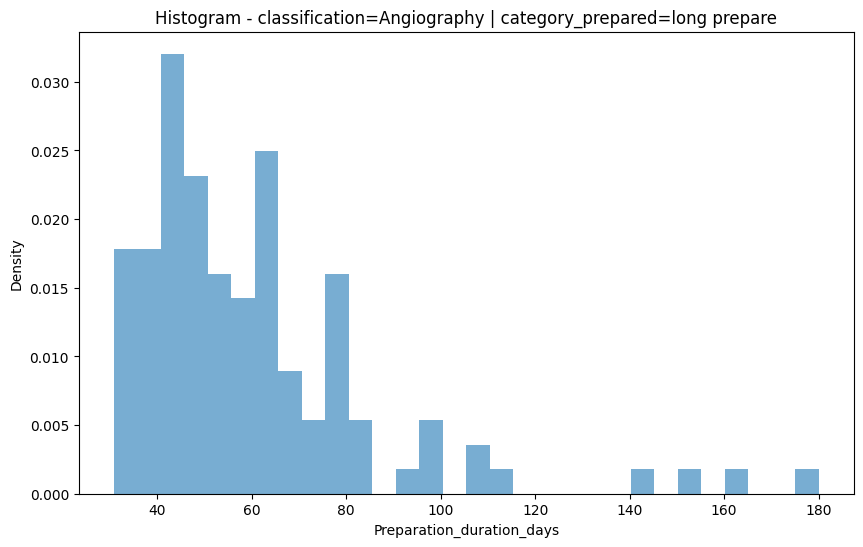

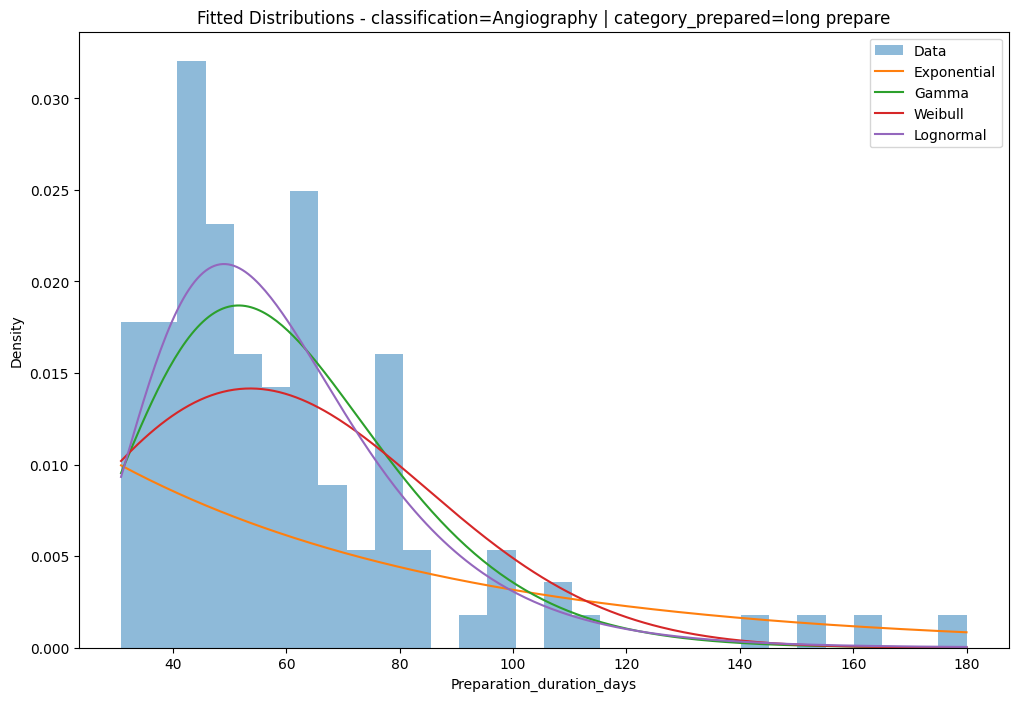

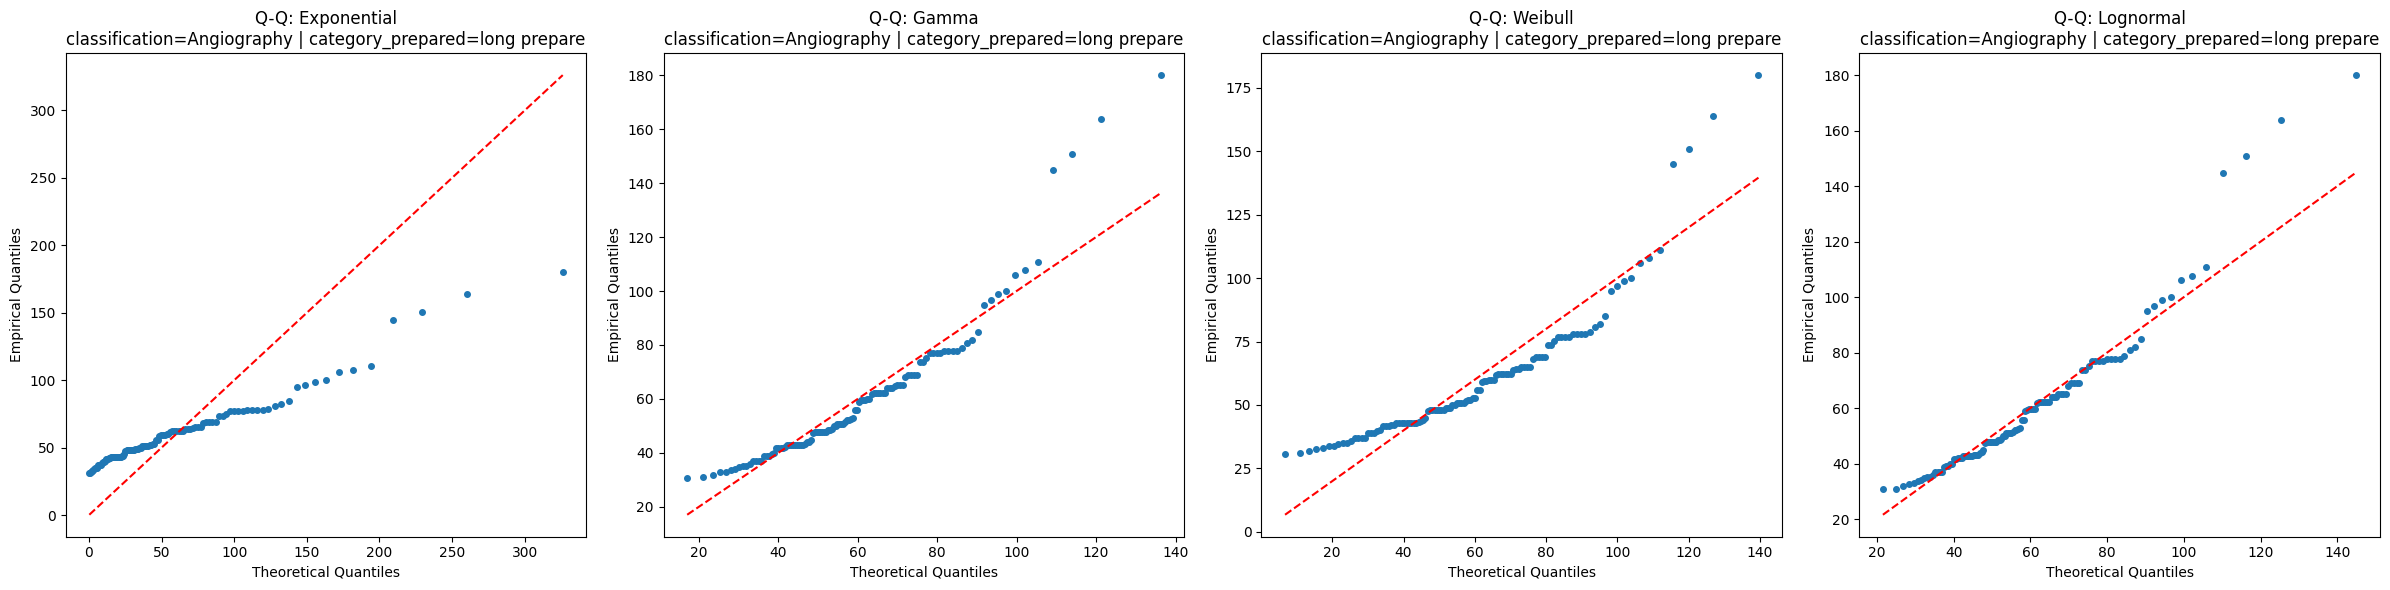


Group: classification=Angiography | category_prepared=medium prepare
n = 228
Mean duration: 15.1060
Std duration: 6.0934
Min duration: 7.0069
Max duration: 29.9257
Average service rate: 0.0662

KS test results:
  distribution      KS_D    KS_p_value        decision
1        Gamma  0.079304  1.076330e-01  Fail to reject
3    Lognormal  0.081022  9.480323e-02  Fail to reject
2      Weibull  0.088915  5.108996e-02  Fail to reject
0  Exponential  0.371143  1.085388e-28          Reject


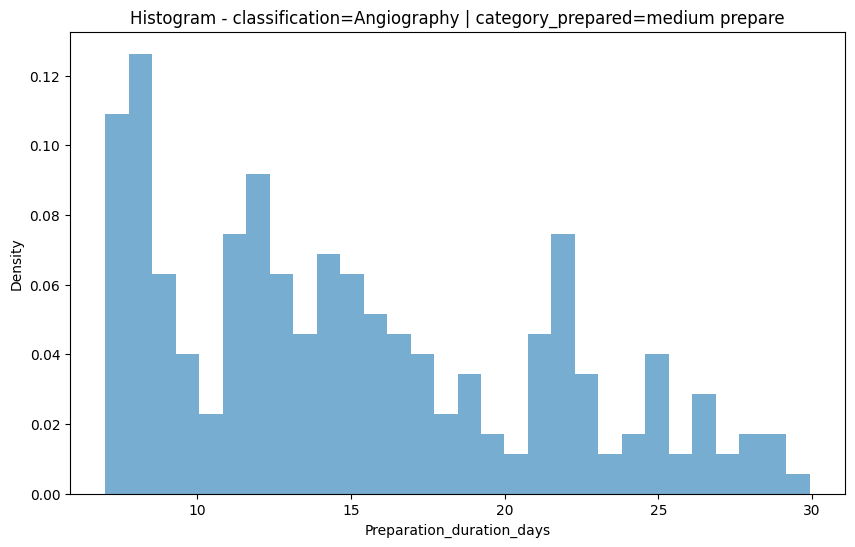

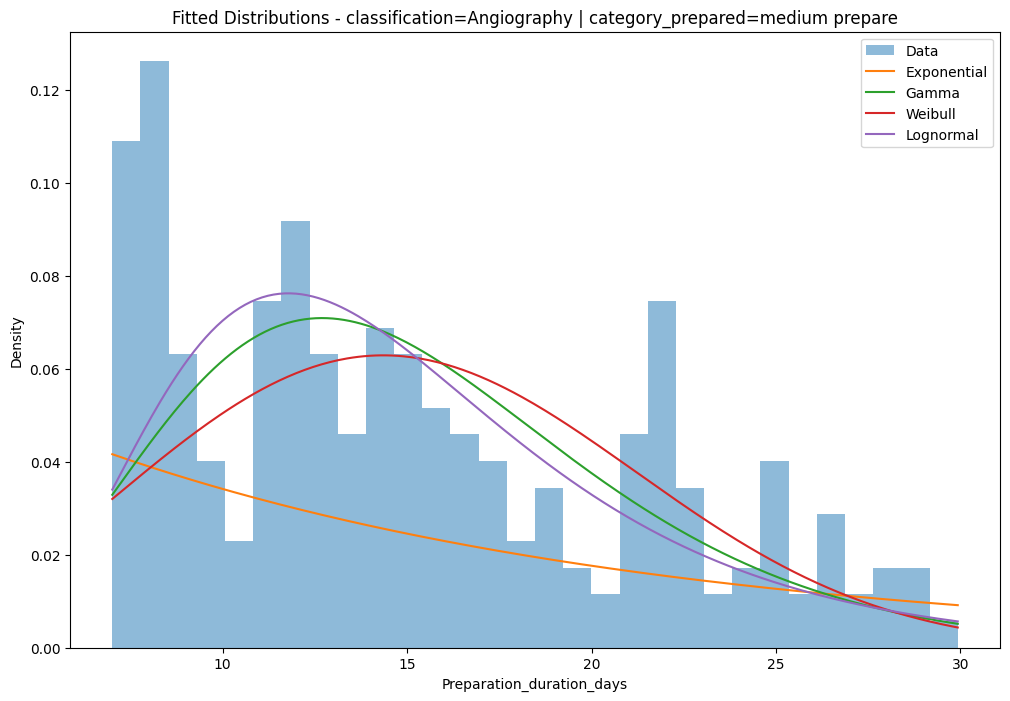

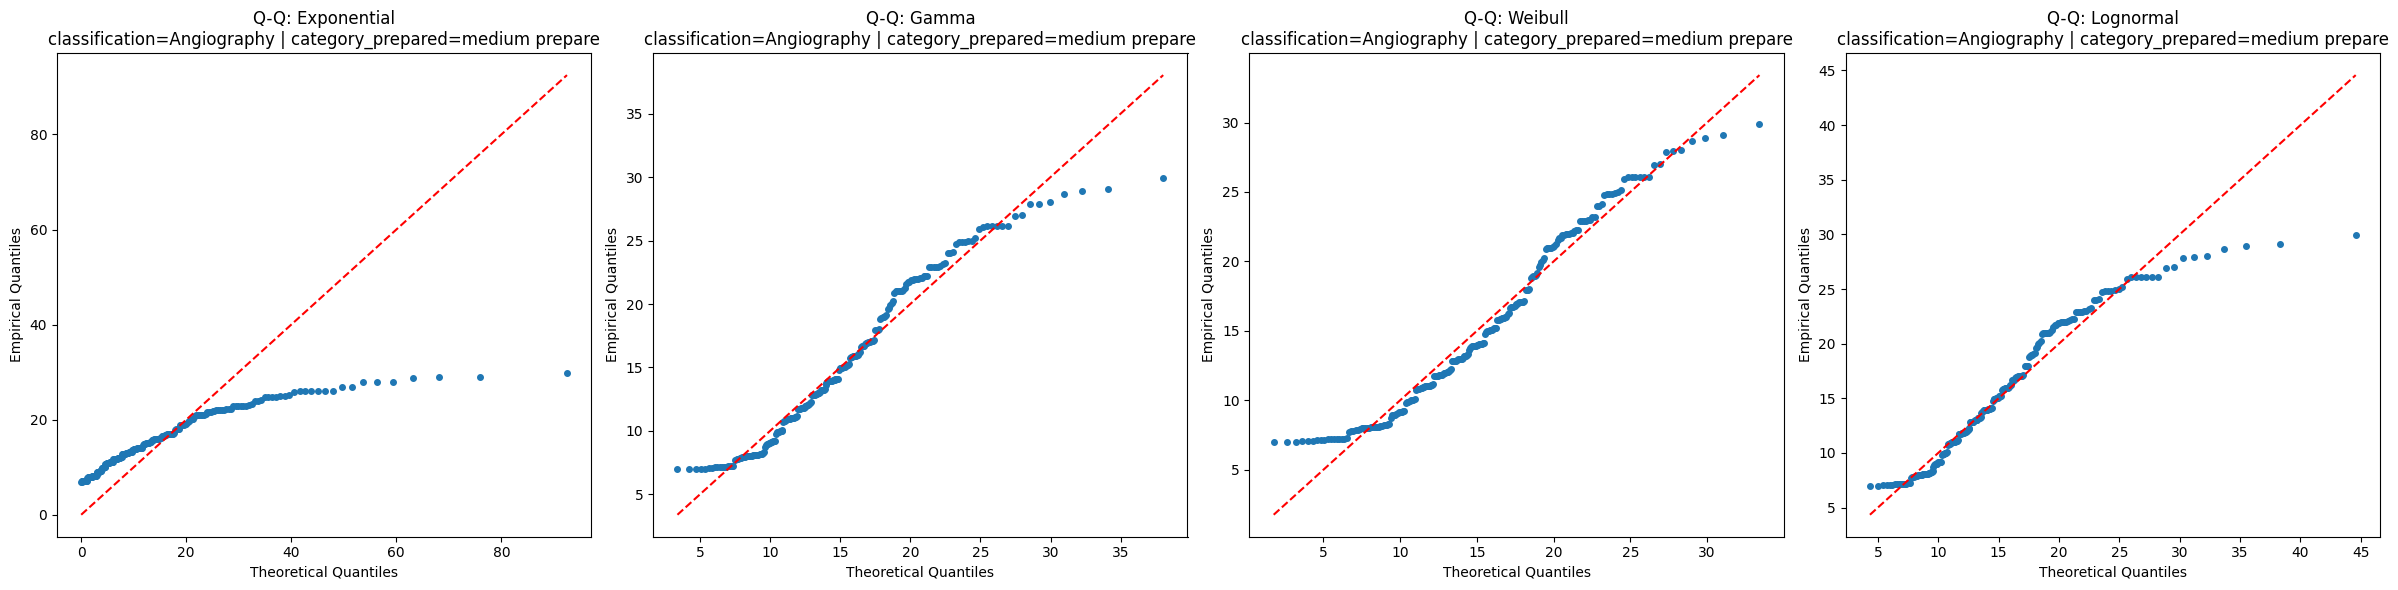


Group: classification=Angiography | category_prepared=no_prepare_required
n = 673
Mean duration: 0.0378
Std duration: 0.0557
Min duration: 0.0007
Max duration: 0.2701
Average service rate: 26.4772

KS test results:
  distribution      KS_D    KS_p_value decision
3    Lognormal  0.116034  2.375259e-08   Reject
2      Weibull  0.132642  8.721569e-11   Reject
1        Gamma  0.163724  3.121824e-16   Reject
0  Exponential  0.290133  1.150456e-50   Reject


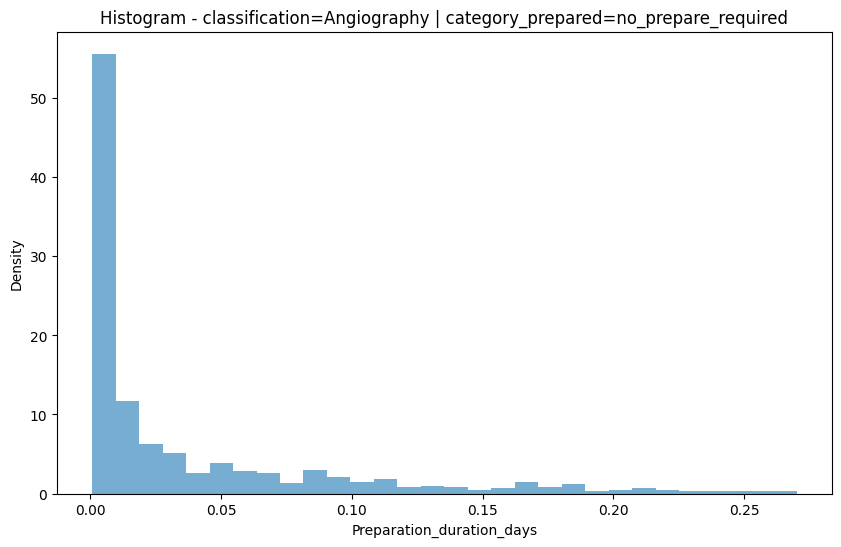

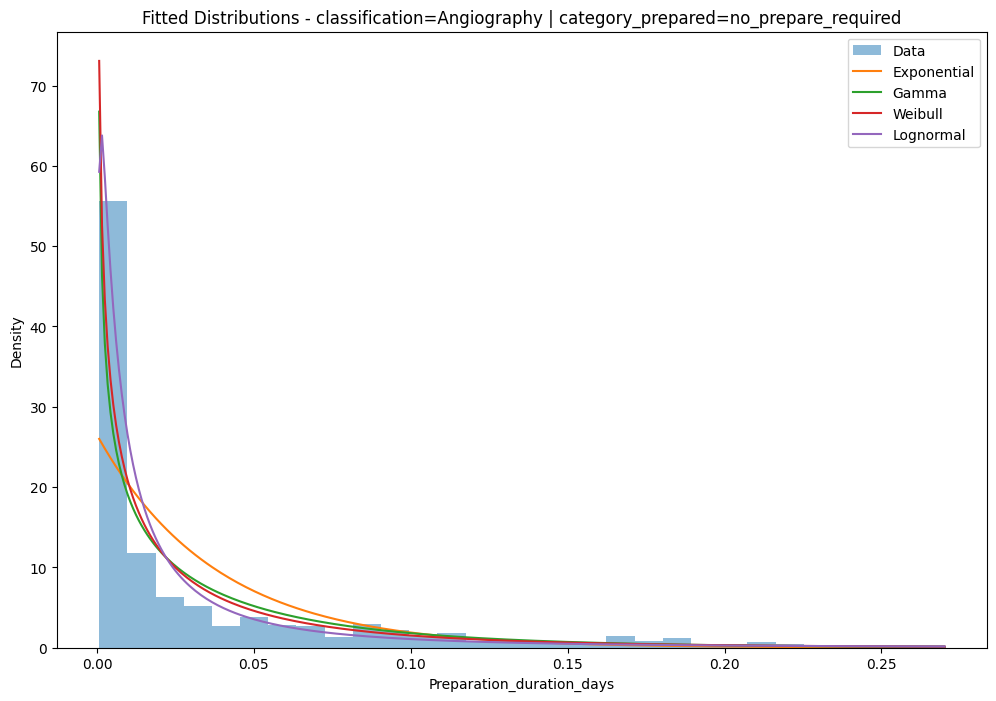

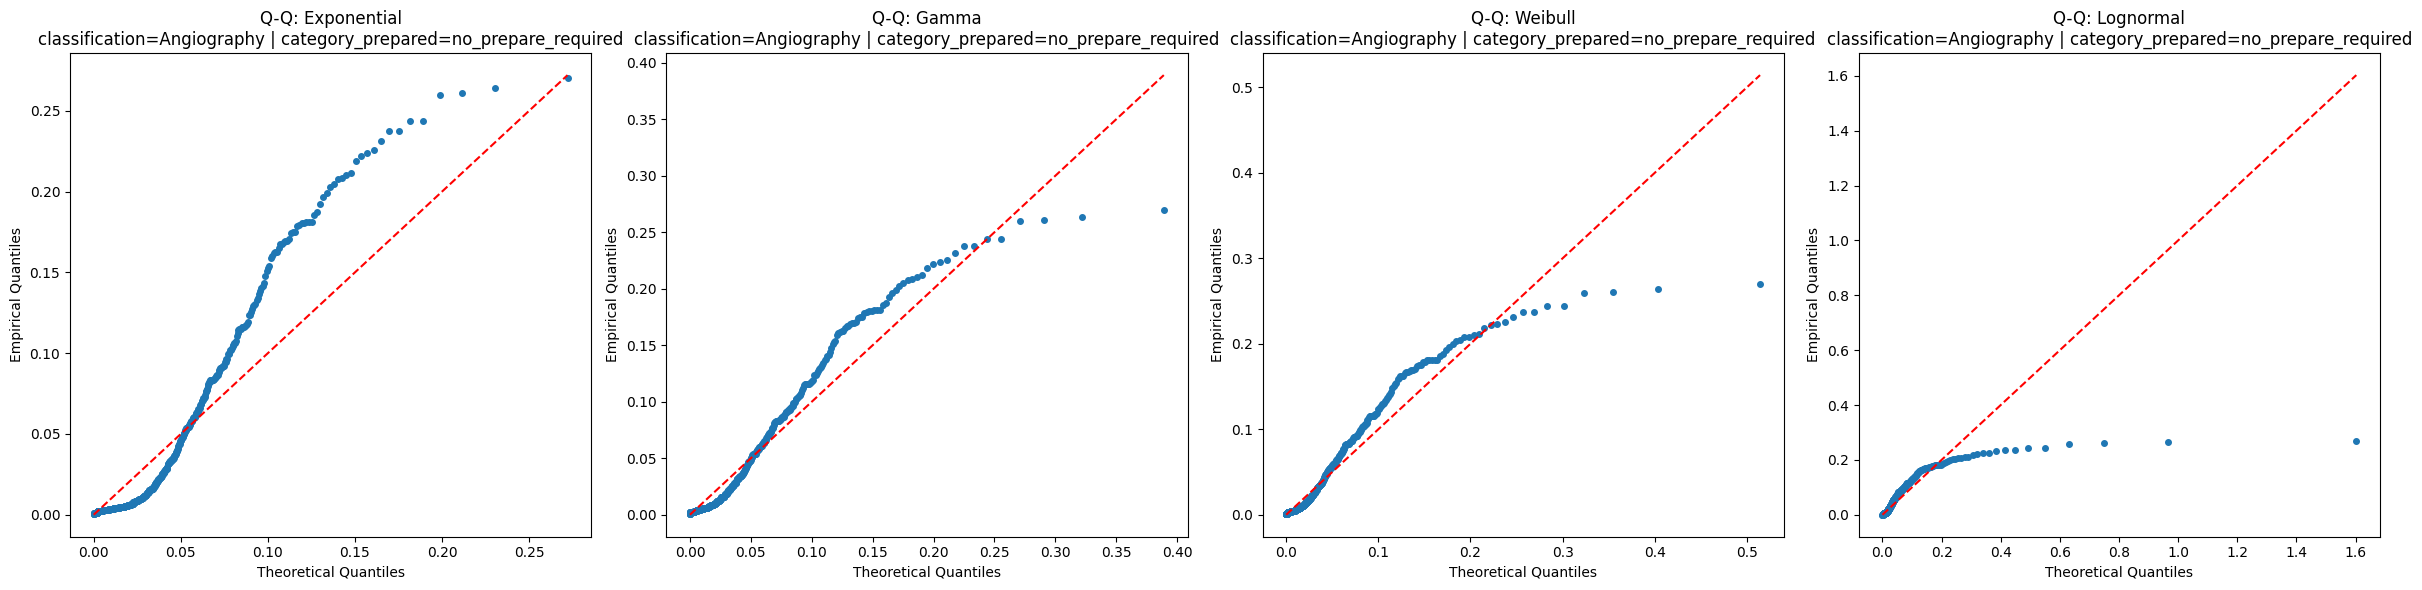


Group: classification=Angiography | category_prepared=short prepare
n = 822
Mean duration: 2.6090
Std duration: 1.9452
Min duration: 0.4326
Max duration: 6.9944
Average service rate: 0.3833

KS test results:
  distribution      KS_D    KS_p_value decision
3    Lognormal  0.166755  1.902628e-20   Reject
2      Weibull  0.174176  2.801204e-22   Reject
1        Gamma  0.179359  1.316218e-23   Reject
0  Exponential  0.203178  3.155566e-30   Reject


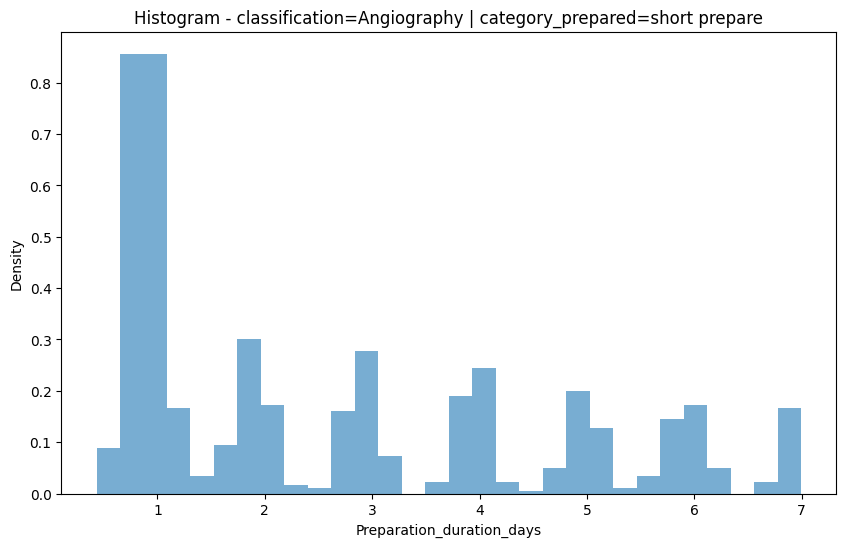

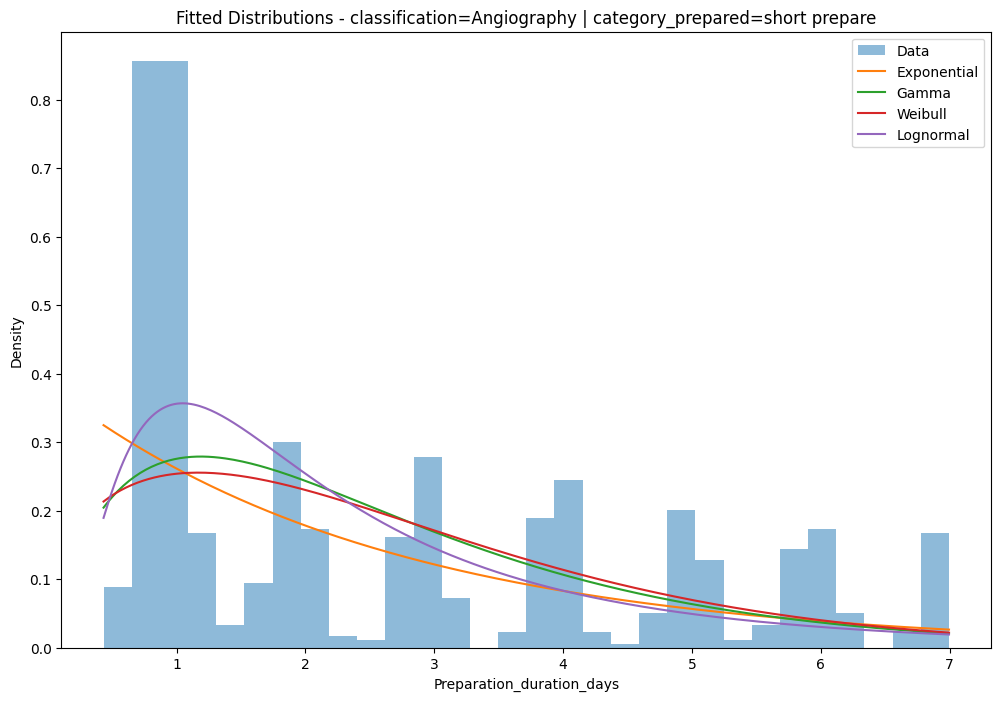

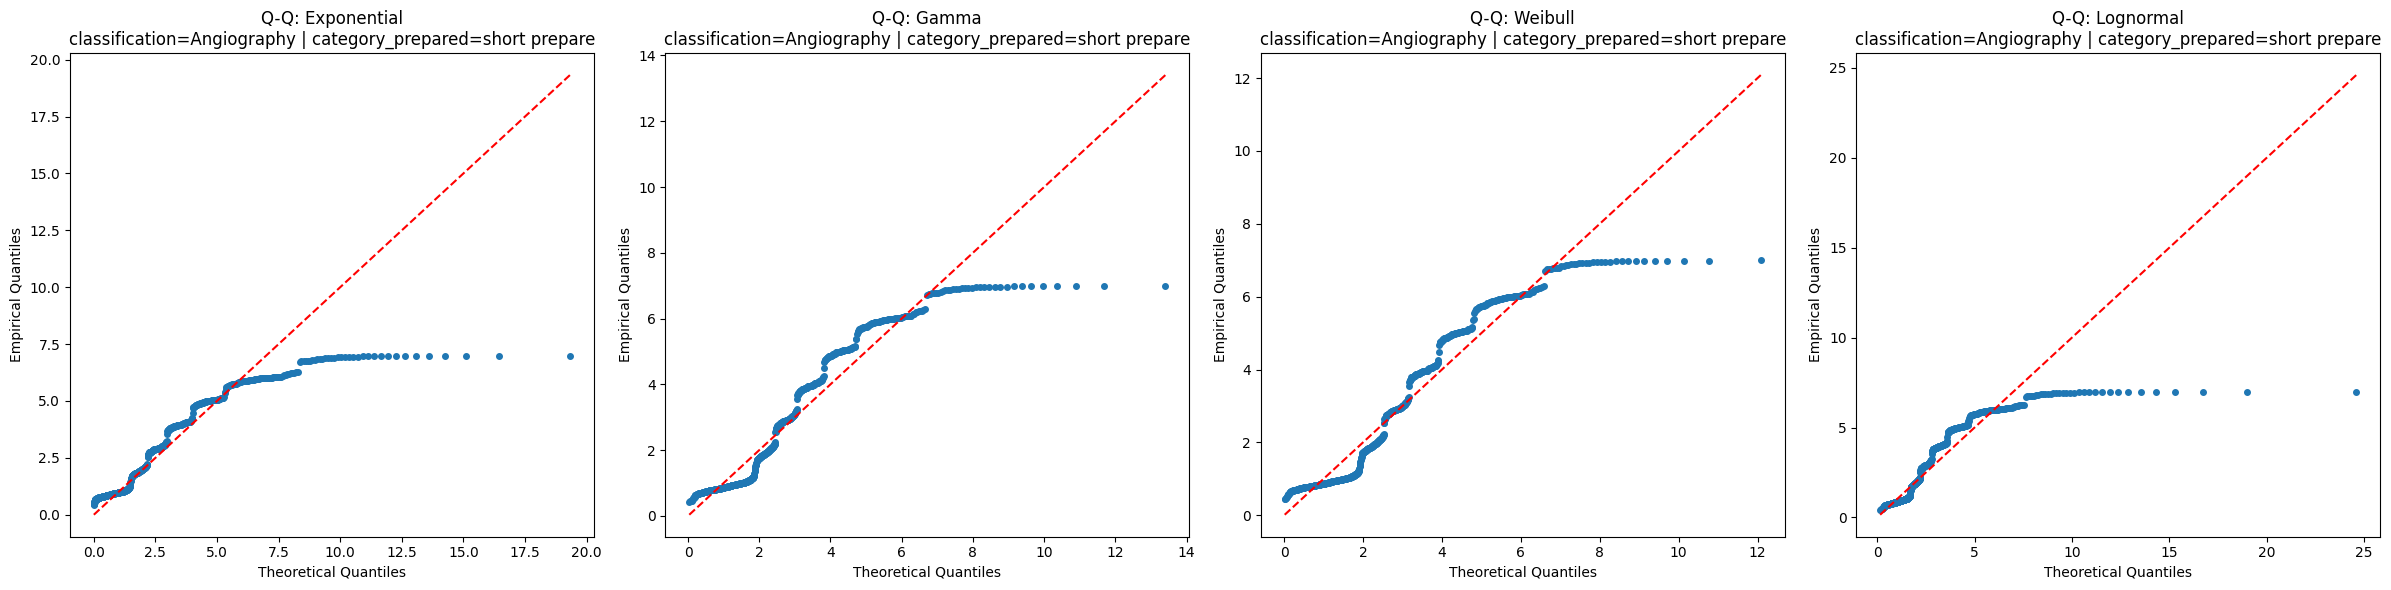


Group: classification=Interventional | category_prepared=long prepare
n = 36
Mean duration: 70.6991
Std duration: 41.5050
Min duration: 32.9431
Max duration: 172.9451
Average service rate: 0.0141

KS test results:
  distribution      KS_D  KS_p_value        decision
3    Lognormal  0.129222    0.541865  Fail to reject
1        Gamma  0.158432    0.294647  Fail to reject
2      Weibull  0.170750    0.218207  Fail to reject
0  Exponential  0.372469    0.000054          Reject


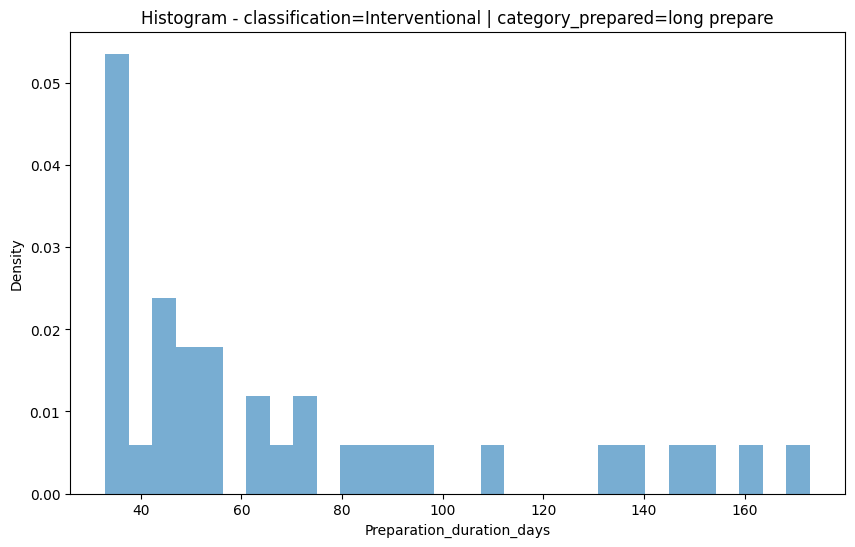

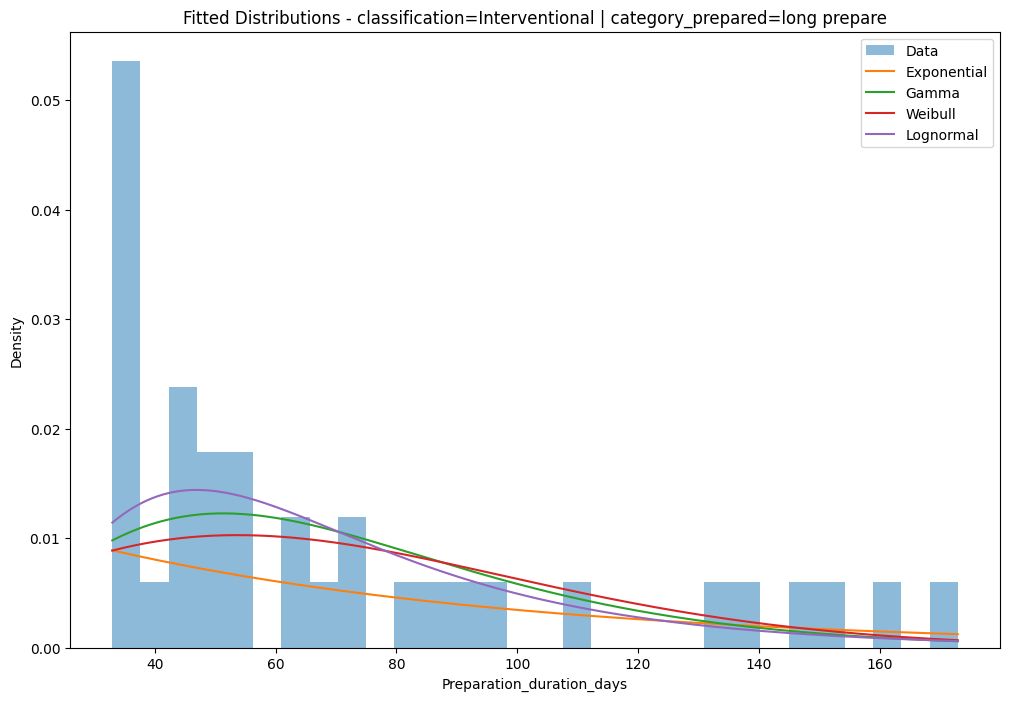

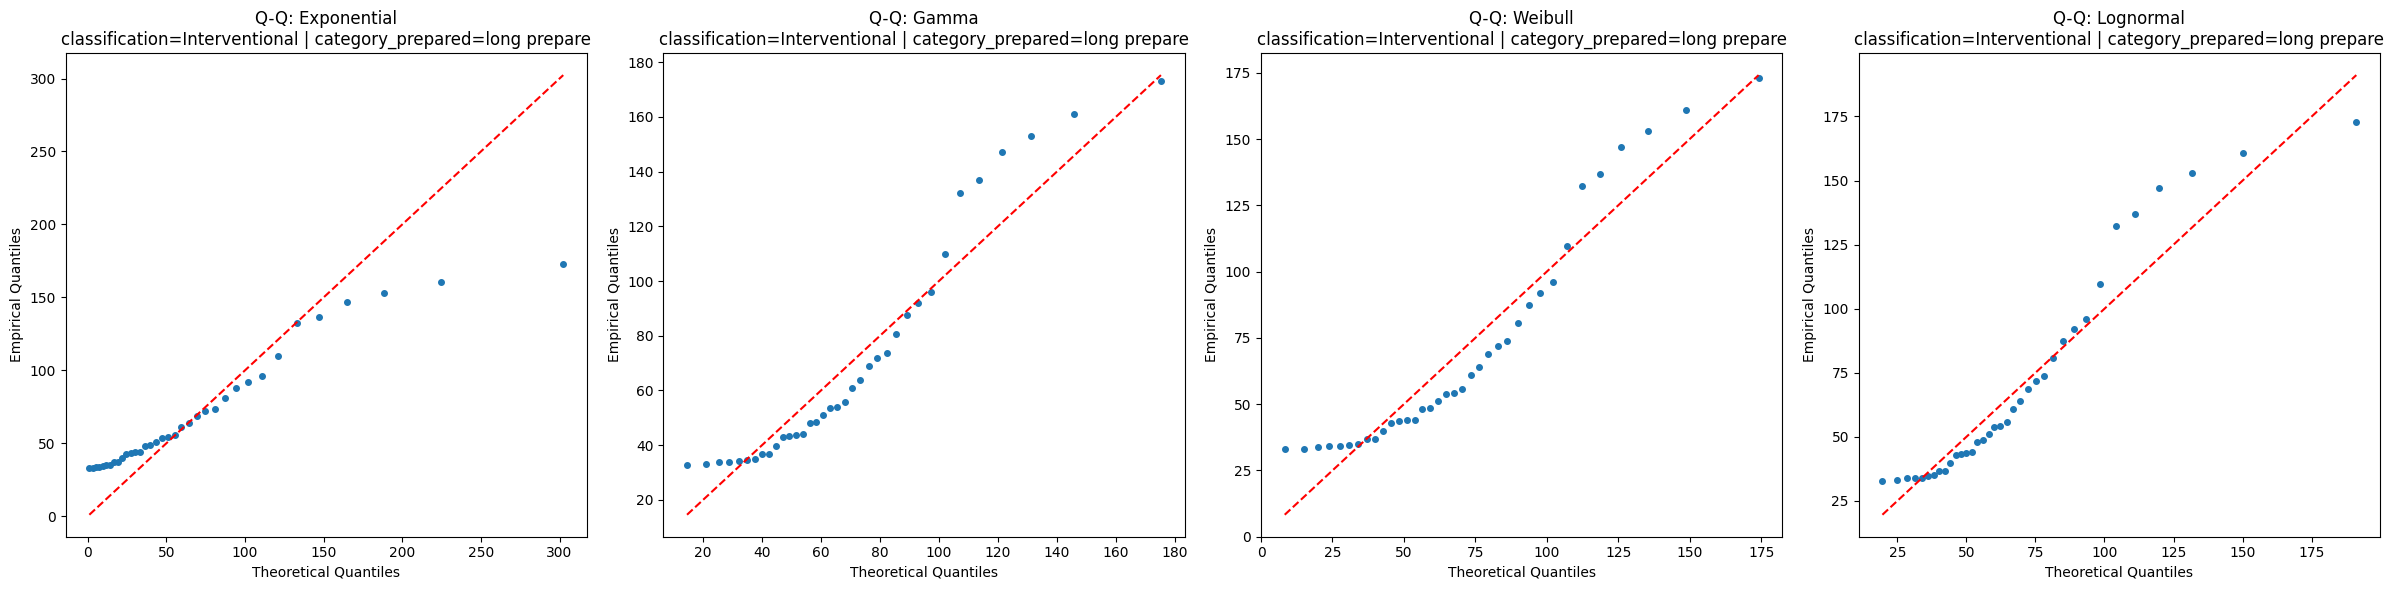


Group: classification=Interventional | category_prepared=medium prepare
n = 69
Mean duration: 14.2235
Std duration: 6.8324
Min duration: 7.0319
Max duration: 29.9799
Average service rate: 0.0703

KS test results:
  distribution      KS_D    KS_p_value        decision
2      Weibull  0.142136  1.114987e-01  Fail to reject
3    Lognormal  0.158355  5.603066e-02  Fail to reject
1        Gamma  0.159377  5.351758e-02  Fail to reject
0  Exponential  0.390057  5.757686e-10          Reject


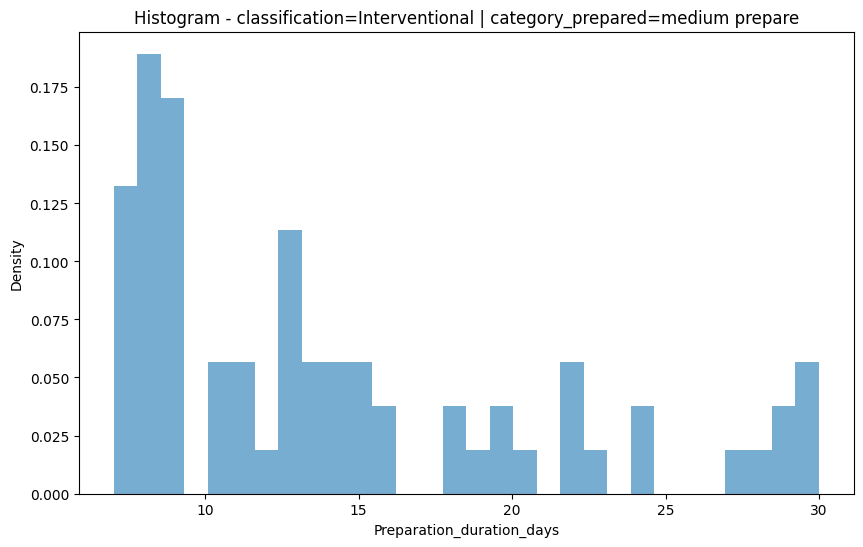

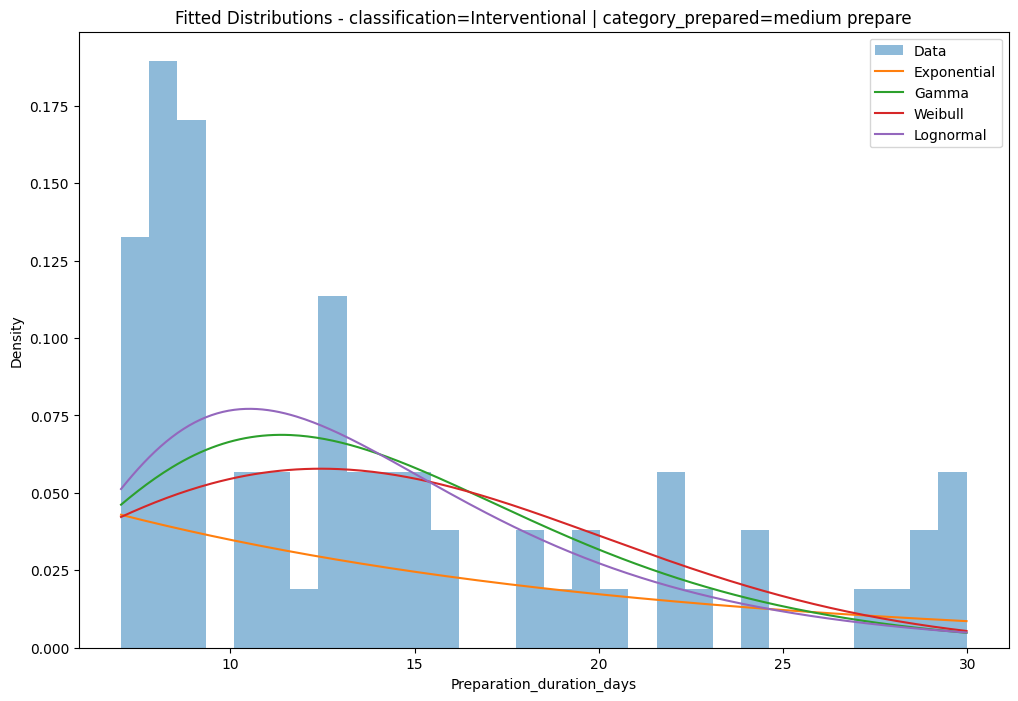

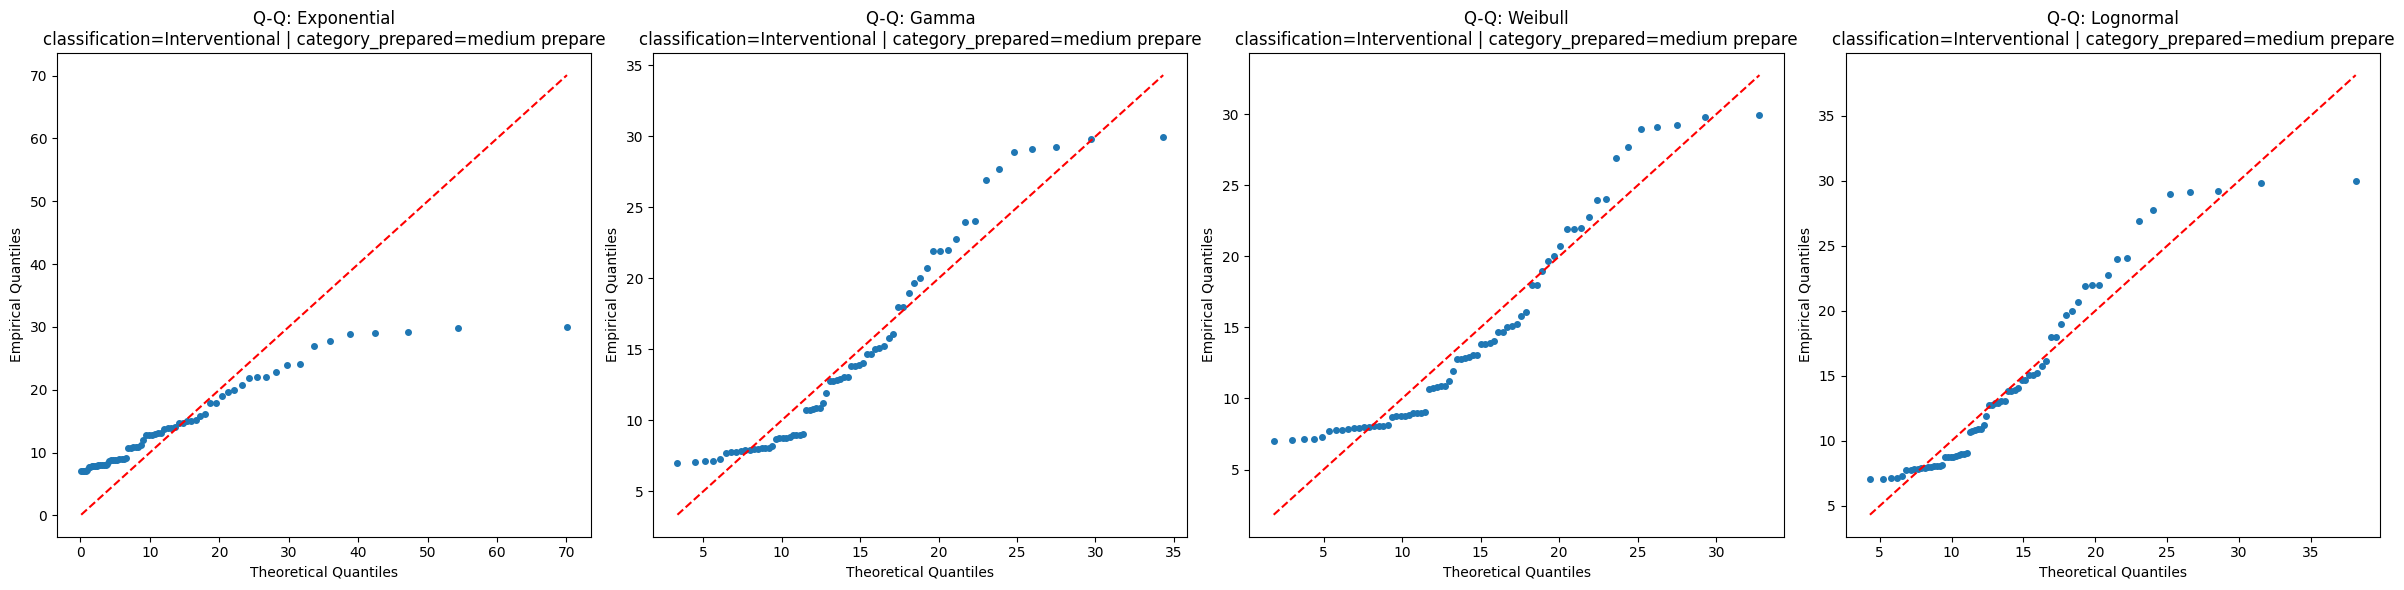


Group: classification=Interventional | category_prepared=no_prepare_required
n = 176
Mean duration: 0.0285
Std duration: 0.0539
Min duration: 0.0007
Max duration: 0.2840
Average service rate: 35.0588

KS test results:
  distribution      KS_D    KS_p_value decision
3    Lognormal  0.192304  3.558624e-06   Reject
2      Weibull  0.223710  3.214825e-08   Reject
1        Gamma  0.274842  3.055707e-12   Reject
0  Exponential  0.465069  2.158775e-35   Reject


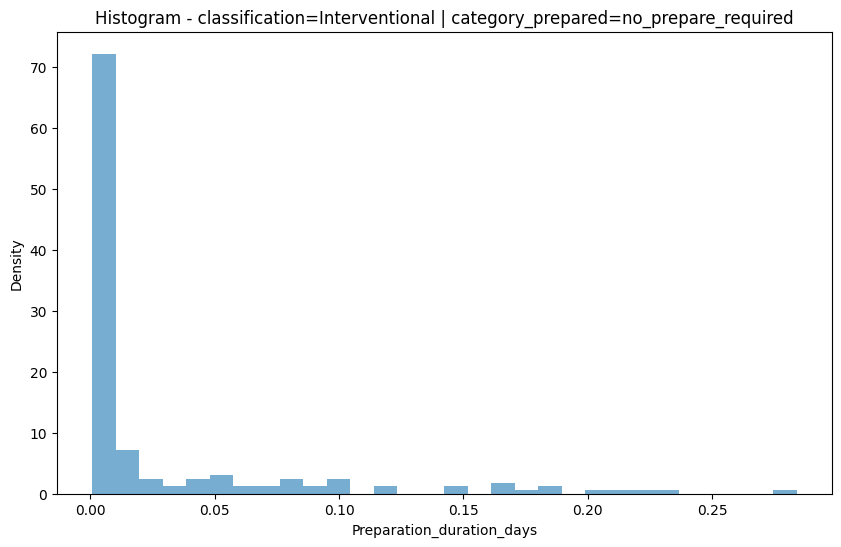

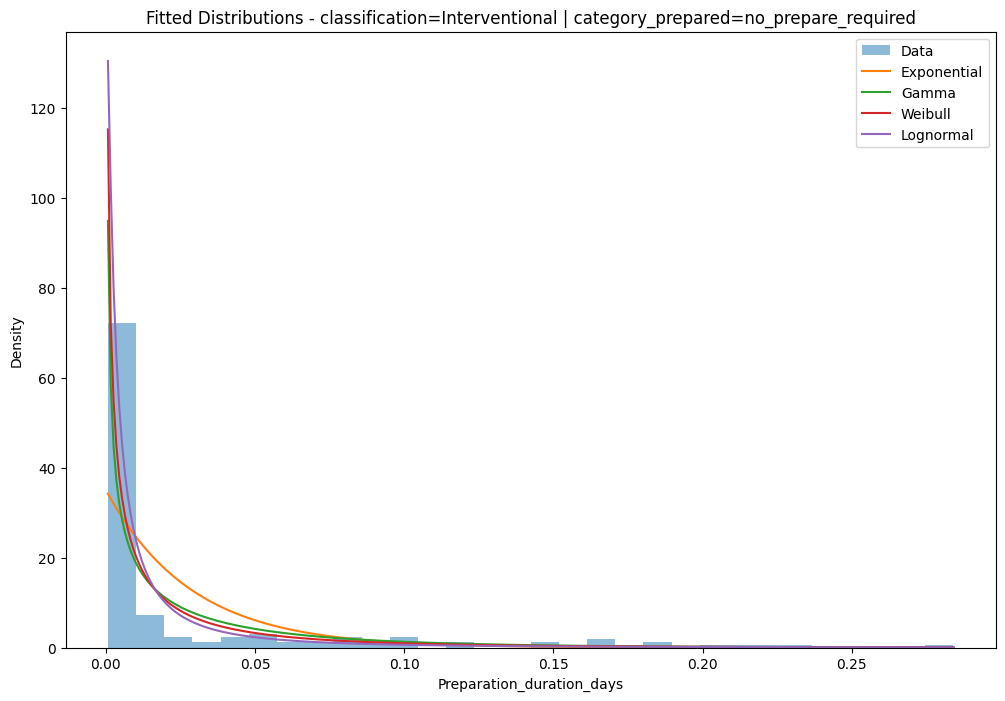

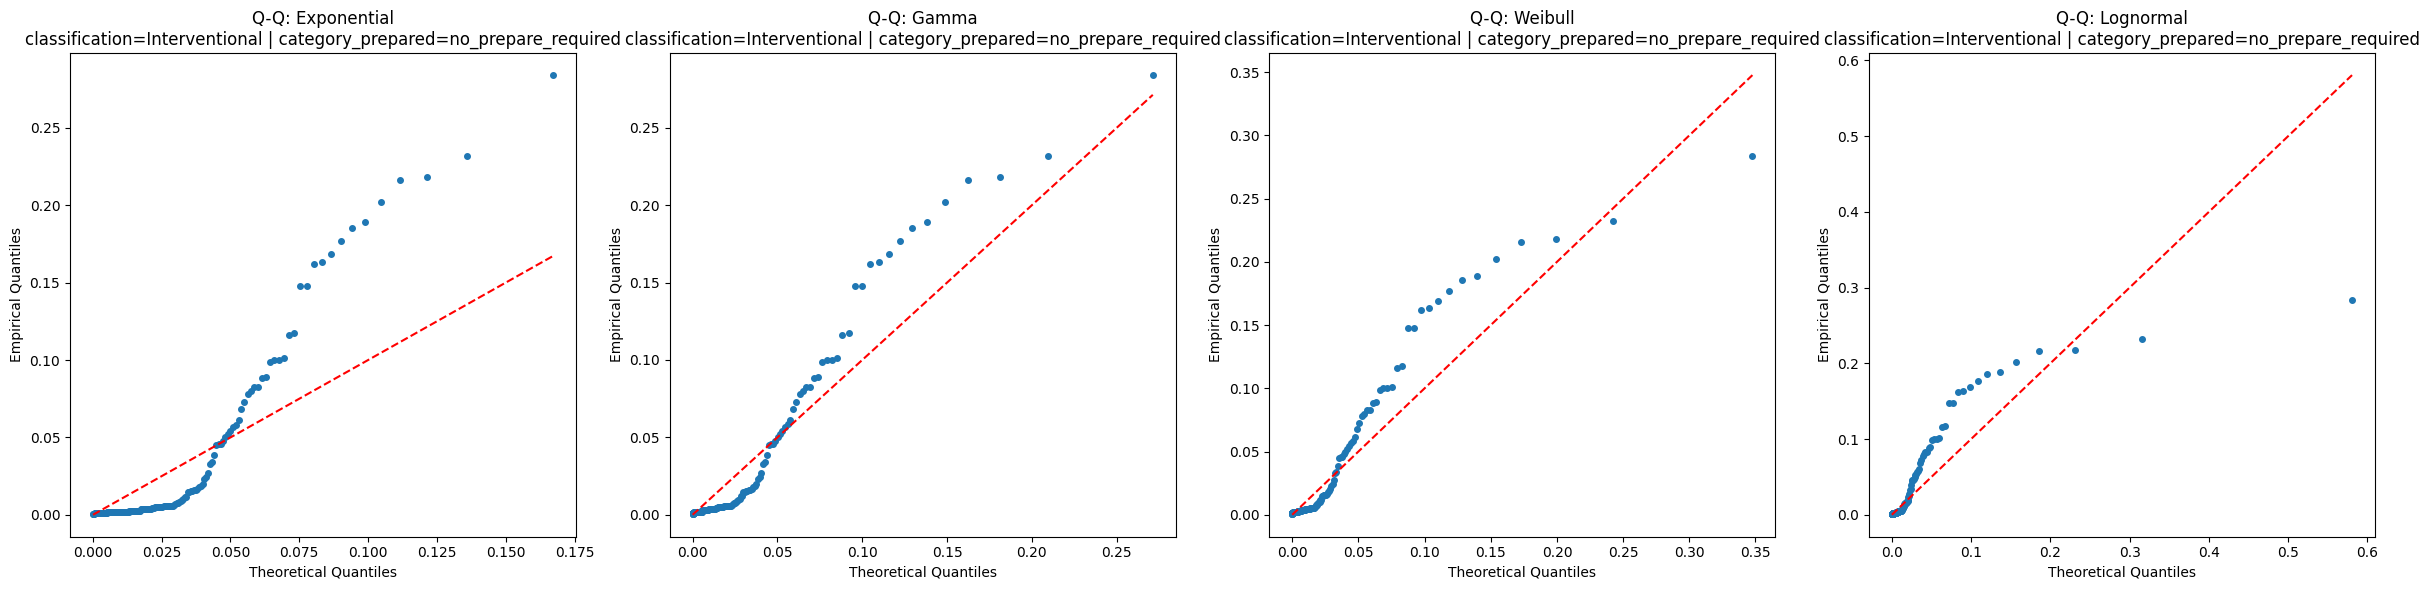


Group: classification=Interventional | category_prepared=short prepare
n = 217
Mean duration: 2.7052
Std duration: 1.9022
Min duration: 0.4618
Max duration: 6.9167
Average service rate: 0.3697

KS test results:
  distribution      KS_D    KS_p_value decision
3    Lognormal  0.131347  1.004307e-03   Reject
2      Weibull  0.136336  5.583861e-04   Reject
1        Gamma  0.140793  3.243611e-04   Reject
0  Exponential  0.192577  1.596330e-07   Reject


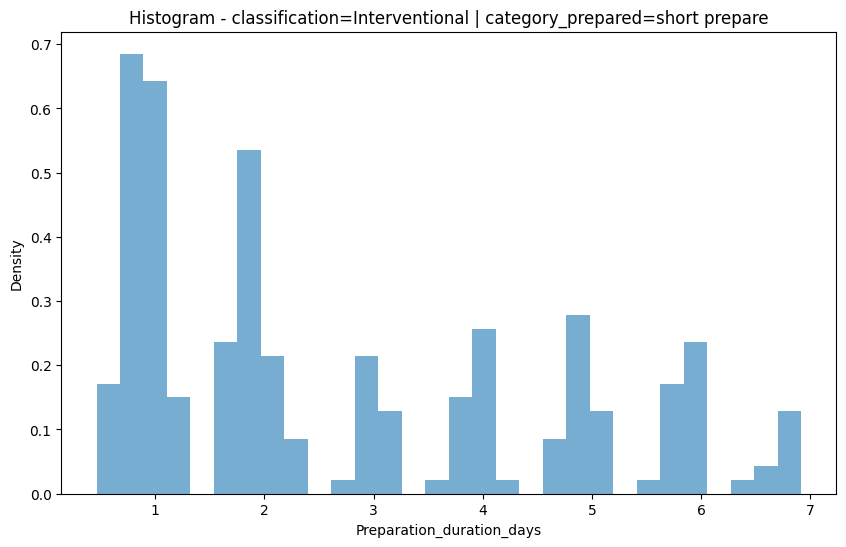

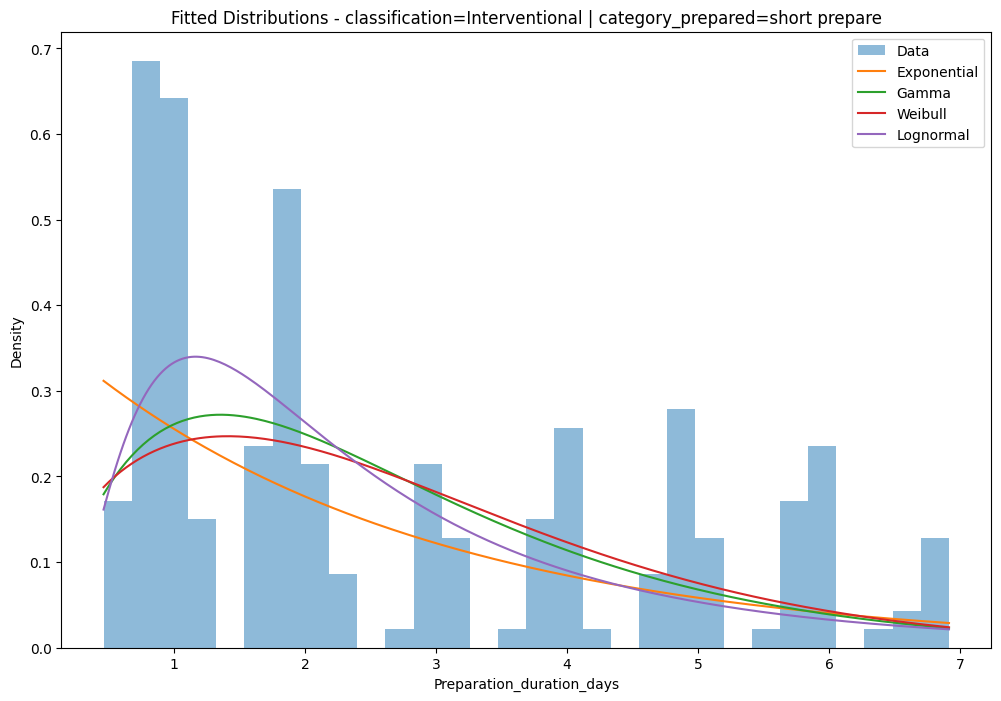

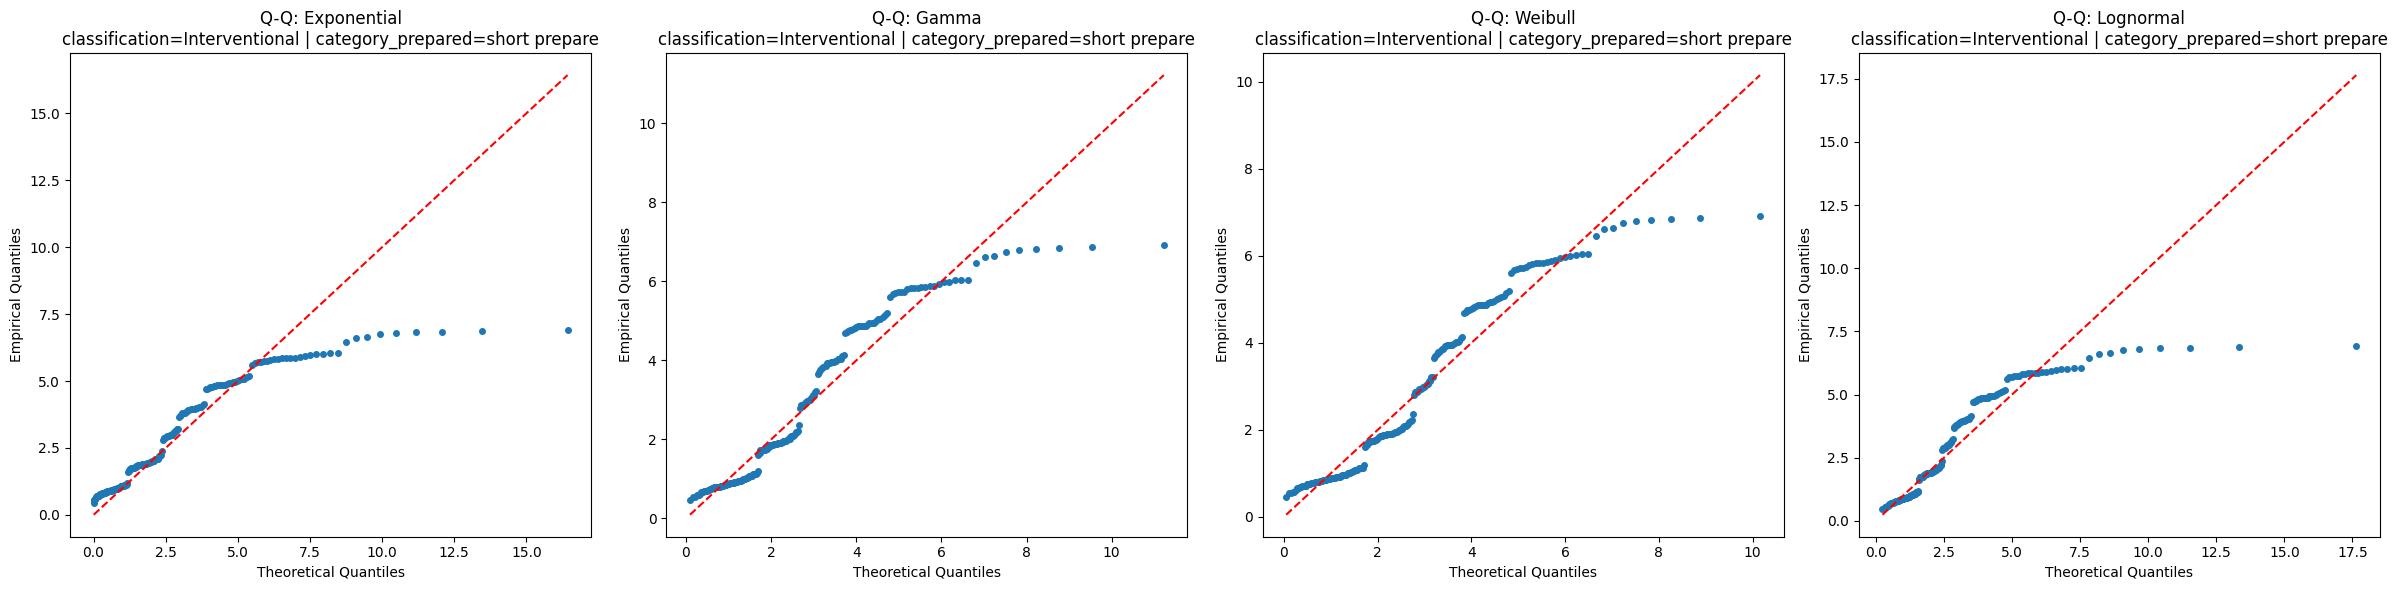


Best result for each group:
                                               group distribution      KS_D  \
0  classification=Angiography | category_prepared...    Lognormal  0.093579   
1  classification=Angiography | category_prepared...        Gamma  0.079304   
2  classification=Angiography | category_prepared...    Lognormal  0.116034   
3  classification=Angiography | category_prepared...    Lognormal  0.166755   
4  classification=Interventional | category_prepa...    Lognormal  0.129222   
5  classification=Interventional | category_prepa...      Weibull  0.142136   
6  classification=Interventional | category_prepa...    Lognormal  0.192304   
7  classification=Interventional | category_prepa...    Lognormal  0.131347   

     KS_p_value        decision    n  mean_duration  service_rate  \
0  2.591093e-01  Fail to reject  113      60.179167      0.016617   
1  1.076330e-01  Fail to reject  228      15.106012      0.066199   
2  2.375259e-08          Reject  673       0.037768 

In [115]:
best_results_df, all_results_df, cleaned_df, outliers_df, fit_params_dict = fit_service_time_distribution(
    df=df_no_weekend,
    duration_col='Preparation_duration_days',
    group_cols=['classification', 'category_prepared'],
    max_days=180,
    alpha=0.05,
    bins=30,
    show_plots=True
)

print("\nBest result for each group:")
print(best_results_df)

print("\nAll KS results:")
print(all_results_df)

# Emperical Distribution for short Perpare

In [116]:
short_angio = df_no_weekend.loc[
    (df_no_weekend['classification'] == 'Angiography') &
    (df_no_weekend['category_prepared'] == 'short prepare'),
    'Preparation_duration_days'
].dropna()

# sample from empirical distribution
sim_samples = np.random.choice(short_angio, size=1000, replace=True)

In [118]:
category_percentage_table = (
    df_no_weekend.groupby(['classification', 'category_prepared'])
    .size()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .unstack(fill_value=0)
)

category_percentage_table

,category_prepared,long prepare,medium prepare,no_prepare_required,short prepare
classification,classification,,,,
Angiography,Angiography,6.460369,12.377850,36.536374,44.625407
Interventional,Interventional,8.333333,13.690476,34.920635,43.055556


# Late Rate

In [119]:
df_no_weekend['LateTime'] = df_no_weekend['ScanStartF'].dt.hour - df_no_weekend['FinalScheduled'].dt.hour / 60

In [120]:
df_no_weekend['LateTime_minutes'] = (
    df_no_weekend['ScanStartF'] - df_no_weekend['FinalScheduled']
).dt.total_seconds() / 60


In [121]:
df_no_weekend['LateTime_minutes'] = (
    (df_no_weekend['ScanStartF'] - df_no_weekend['FinalScheduled'])
    .dt.total_seconds() / 60
)

df_no_weekend = df_no_weekend[df_no_weekend['LateTime_minutes'] > -10].copy()


In [122]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt


def fit_service_time_distribution(
    df,
    duration_col,
    class_col=None,
    max_hours=6,
    min_positive=True,
    bins=30,
    alpha=0.05,
    show_plots=True
):
    """
    Fit service-time distributions to a duration column in hours.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    duration_col : str
        Column containing service duration in hours.
    class_col : str or None
        Optional classification column. If given, fit separately by class.
    max_hours : float or None
        Drop durations greater than this threshold. If None, keep all.
    min_positive : bool
        If True, keep only durations > 0.
    bins : int
        Number of histogram bins.
    alpha : float
        Significance level for KS test.
    show_plots : bool
        Whether to show histogram, fitted curves, and Q-Q plots.

    Returns
    -------
    results_df : pandas.DataFrame
        Summary of fitted results.
    cleaned_df : pandas.DataFrame
        Cleaned dataframe used for fitting.
    outliers_df : pandas.DataFrame
        Outliers removed because duration > max_hours.
    """

    df_work = df.copy()

    # keep outliers separately
    if max_hours is not None:
        outliers_df = df_work[df_work[duration_col] > max_hours].copy()
    else:
        outliers_df = df_work.iloc[0:0].copy()

    # cleaning
    mask = df_work[duration_col].notna()

    if min_positive:
        mask &= df_work[duration_col] > 0

    if max_hours is not None:
        mask &= df_work[duration_col] <= max_hours

    df_work = df_work.loc[mask].copy()

    print(f"Number kept: {len(df_work)}")
    print(f"Number dropped as outliers: {len(outliers_df)}")

    # decide grouping
    if class_col is None:
        groups = [('All', df_work)]
    else:
        groups = list(df_work.groupby(class_col))

    all_results = []

    for group_name, group_df in groups:
        service_data = group_df[duration_col].dropna().astype(float)

        if len(service_data) < 5:
            print(f"\n{group_name}: not enough data to fit.")
            continue

        print("\n" + "=" * 90)
        print(f"Group: {group_name}")
        print(f"n = {len(service_data)}")
        print(f"Mean duration (hours): {service_data.mean():.4f}")
        print(f"Std duration (hours): {service_data.std():.4f}")
        print(f"Min duration (hours): {service_data.min():.4f}")
        print(f"Max duration (hours): {service_data.max():.4f}")

        mean_service_time = service_data.mean()
        mu = 1 / mean_service_time
        print(f"Average service rate (patients/hour): {mu:.4f}")

        # fit distributions
        exp_loc, exp_scale = stats.expon.fit(service_data, floc=0)
        exp_params = (exp_loc, exp_scale)

        gamma_a, gamma_loc, gamma_scale = stats.gamma.fit(service_data, floc=0)
        gamma_params = (gamma_a, gamma_loc, gamma_scale)

        weibull_c, weibull_loc, weibull_scale = stats.weibull_min.fit(service_data, floc=0)
        weibull_params = (weibull_c, weibull_loc, weibull_scale)

        lognorm_sigma, lognorm_loc, lognorm_scale = stats.lognorm.fit(service_data, floc=0)
        lognorm_params = (lognorm_sigma, lognorm_loc, lognorm_scale)

        # KS tests
        ks_results = []

        for dist_name, scipy_name, params in [
            ('Exponential', 'expon', exp_params),
            ('Gamma', 'gamma', gamma_params),
            ('Weibull', 'weibull_min', weibull_params),
            ('Lognormal', 'lognorm', lognorm_params)
        ]:
            D, p_value = stats.kstest(service_data, scipy_name, args=params)
            decision = "Fail to reject" if p_value >= alpha else "Reject"

            ks_results.append({
                'group': group_name,
                'distribution': dist_name,
                'KS_D': D,
                'KS_p_value': p_value,
                'decision': decision
            })

        ks_df = pd.DataFrame(ks_results).sort_values(['KS_D', 'KS_p_value'], ascending=[True, False])

        print("\nKS test results:")
        print(ks_df[['distribution', 'KS_D', 'KS_p_value', 'decision']])

        # plots
        if show_plots:
            # histogram
            plt.figure(figsize=(10, 6))
            plt.hist(service_data, bins=bins, density=True, alpha=0.6)
            plt.title(f'Histogram of Service Duration (Hours) - {group_name}')
            plt.xlabel('Service Duration (Hours)')
            plt.ylabel('Density')
            plt.show()

            # fitted curves
            plt.figure(figsize=(12, 8))
            plt.hist(service_data, bins=bins, density=True, alpha=0.5, label='Data')

            x = np.linspace(service_data.min(), service_data.max(), 300)
            plt.plot(x, stats.expon.pdf(x, *exp_params), label='Exponential')
            plt.plot(x, stats.gamma.pdf(x, *gamma_params), label='Gamma')
            plt.plot(x, stats.weibull_min.pdf(x, *weibull_params), label='Weibull')
            plt.plot(x, stats.lognorm.pdf(x, *lognorm_params), label='Lognormal')

            plt.title(f'Service Duration (Hours) with Fitted Distributions - {group_name}')
            plt.xlabel('Service Duration (Hours)')
            plt.ylabel('Density')
            plt.legend()
            plt.show()

            # QQ plots
            fig, axs = plt.subplots(1, 4, figsize=(24, 6))

            sorted_data = np.sort(service_data)
            prob = (np.arange(1, len(service_data) + 1) - 0.5) / len(service_data)

            theoretical_exp = stats.expon.ppf(prob, *exp_params)
            axs[0].plot(theoretical_exp, sorted_data, 'o', markersize=4)
            axs[0].plot(theoretical_exp, theoretical_exp, 'r--')
            axs[0].set_title(f"Q-Q Plot: Exponential\n{group_name}")

            theoretical_gamma = stats.gamma.ppf(prob, *gamma_params)
            axs[1].plot(theoretical_gamma, sorted_data, 'o', markersize=4)
            axs[1].plot(theoretical_gamma, theoretical_gamma, 'r--')
            axs[1].set_title(f"Q-Q Plot: Gamma\n{group_name}")

            theoretical_weibull = stats.weibull_min.ppf(prob, *weibull_params)
            axs[2].plot(theoretical_weibull, sorted_data, 'o', markersize=4)
            axs[2].plot(theoretical_weibull, theoretical_weibull, 'r--')
            axs[2].set_title(f"Q-Q Plot: Weibull\n{group_name}")

            theoretical_lognorm = stats.lognorm.ppf(prob, *lognorm_params)
            axs[3].plot(theoretical_lognorm, sorted_data, 'o', markersize=4)
            axs[3].plot(theoretical_lognorm, theoretical_lognorm, 'r--')
            axs[3].set_title(f"Q-Q Plot: Lognormal\n{group_name}")

            for ax in axs:
                ax.set_xlabel("Theoretical Quantiles")
                ax.set_ylabel("Empirical Quantiles")

            plt.tight_layout()
            plt.show()

        best_row = ks_df.iloc[0].copy()

        best_row['n'] = len(service_data)
        best_row['mean_duration_hours'] = mean_service_time
        best_row['service_rate_per_hour'] = mu

        if best_row['distribution'] == 'Exponential':
            best_row['param_1_name'] = 'loc'
            best_row['param_1_value'] = exp_loc
            best_row['param_2_name'] = 'scale'
            best_row['param_2_value'] = exp_scale

        elif best_row['distribution'] == 'Gamma':
            best_row['param_1_name'] = 'shape'
            best_row['param_1_value'] = gamma_a
            best_row['param_2_name'] = 'loc'
            best_row['param_2_value'] = gamma_loc
            best_row['param_3_name'] = 'scale'
            best_row['param_3_value'] = gamma_scale

        elif best_row['distribution'] == 'Weibull':
            best_row['param_1_name'] = 'shape'
            best_row['param_1_value'] = weibull_c
            best_row['param_2_name'] = 'loc'
            best_row['param_2_value'] = weibull_loc
            best_row['param_3_name'] = 'scale'
            best_row['param_3_value'] = weibull_scale

        elif best_row['distribution'] == 'Lognormal':
            best_row['param_1_name'] = 'sigma'
            best_row['param_1_value'] = lognorm_sigma
            best_row['param_2_name'] = 'loc'
            best_row['param_2_value'] = lognorm_loc
            best_row['param_3_name'] = 'scale'
            best_row['param_3_value'] = lognorm_scale

        all_results.append(best_row)


    results_df = pd.DataFrame(all_results)
    return results_df, df_work, outliers_df

Number kept: 1821
Number dropped as outliers: 7

Group: Angiography
n = 1419
Mean duration (hours): 52.5462
Std duration (hours): 46.5104
Min duration (hours): 1.0000
Max duration (hours): 330.0000
Average service rate (patients/hour): 0.0190

KS test results:
  distribution      KS_D    KS_p_value        decision
1        Gamma  0.032651  9.494150e-02  Fail to reject
2      Weibull  0.039250  2.457528e-02          Reject
3    Lognormal  0.084587  2.786414e-09          Reject
0  Exponential  0.094705  1.579811e-11          Reject


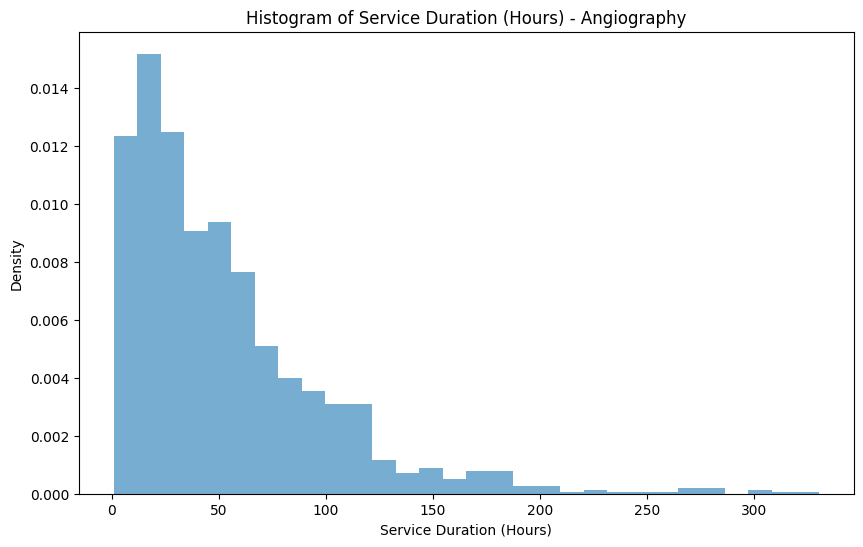

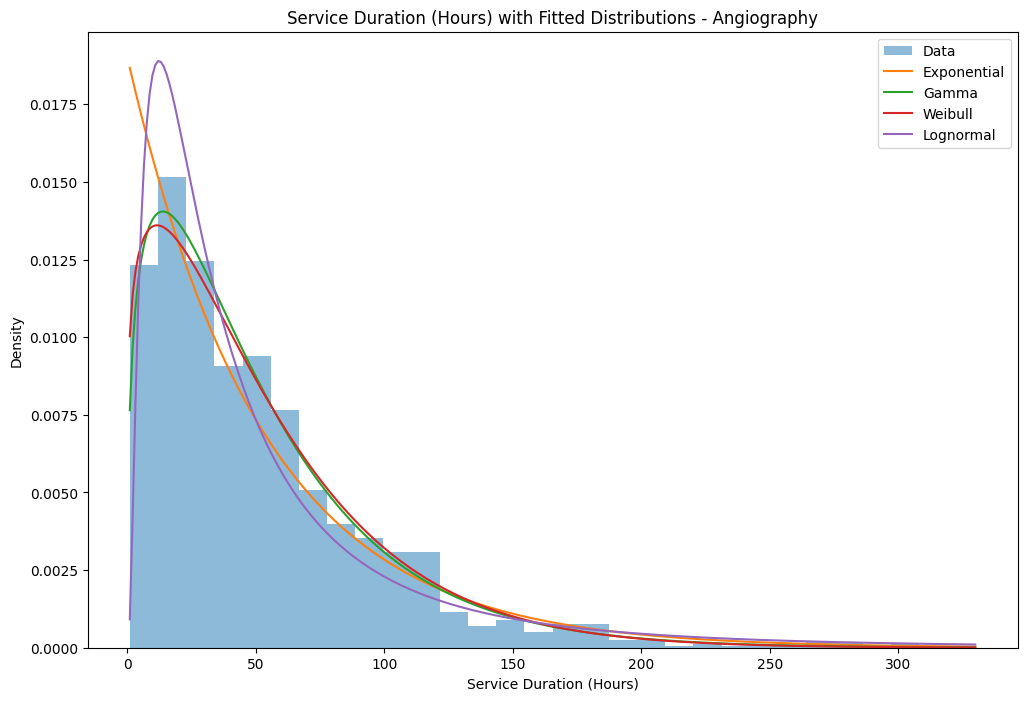

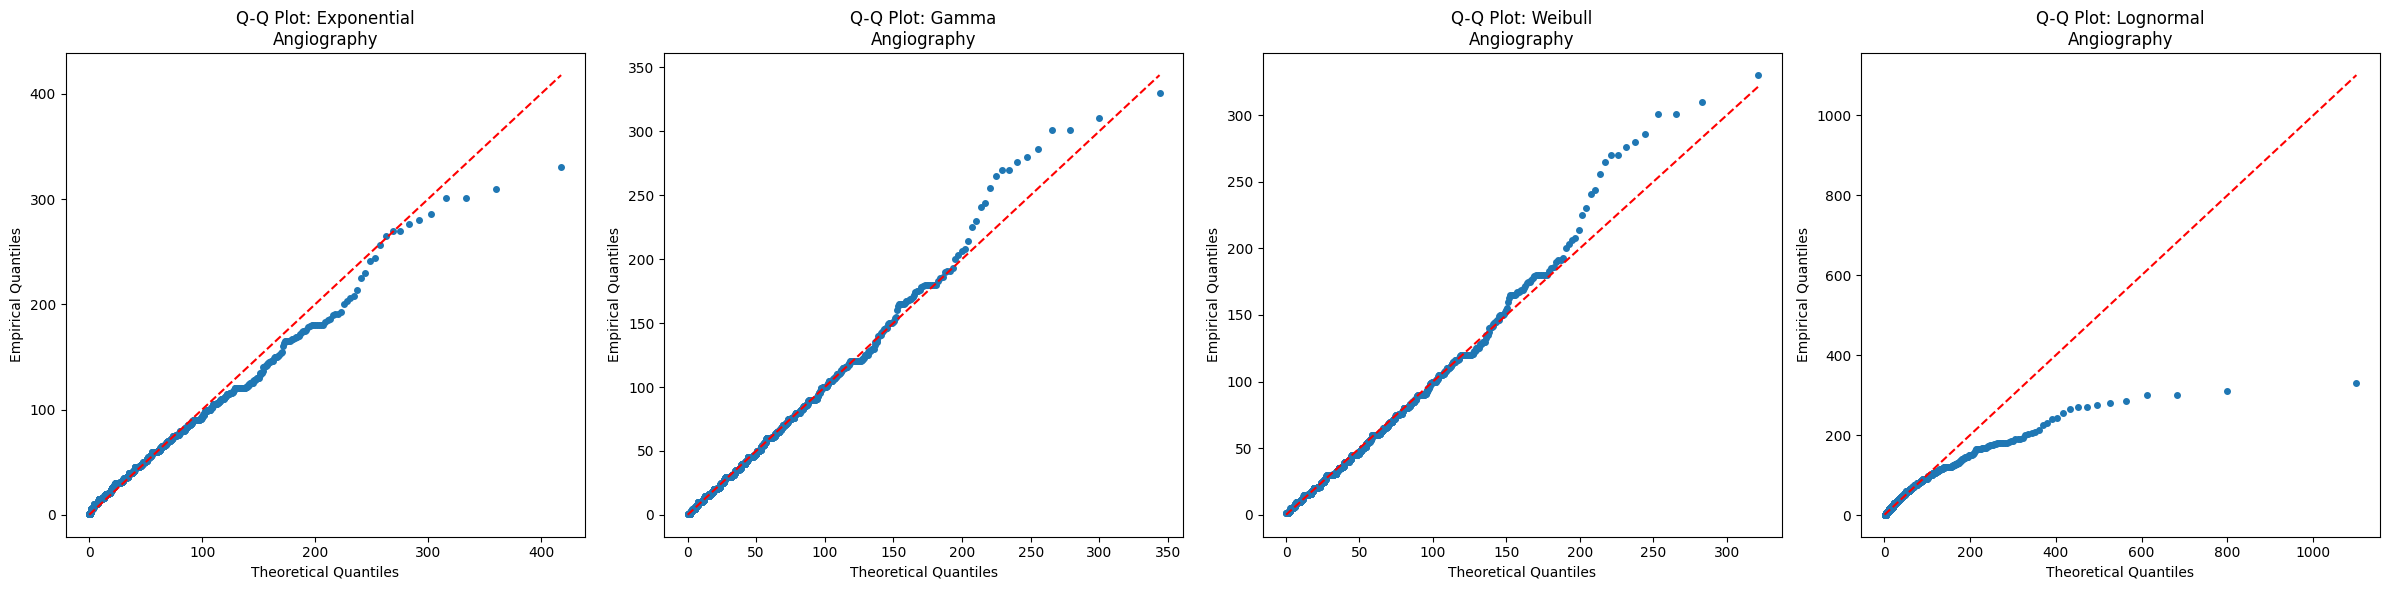


Group: Interventional
n = 402
Mean duration (hours): 65.6418
Std duration (hours): 50.6268
Min duration (hours): 1.0000
Max duration (hours): 316.0000
Average service rate (patients/hour): 0.0152

KS test results:
  distribution      KS_D    KS_p_value        decision
1        Gamma  0.034201  7.214923e-01  Fail to reject
2      Weibull  0.042999  4.349967e-01  Fail to reject
3    Lognormal  0.087539  3.952092e-03          Reject
0  Exponential  0.135493  6.738102e-07          Reject


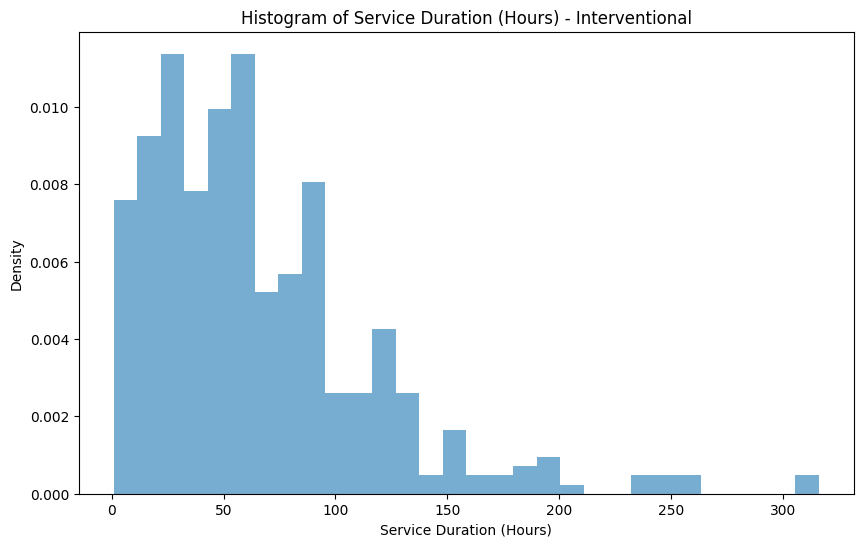

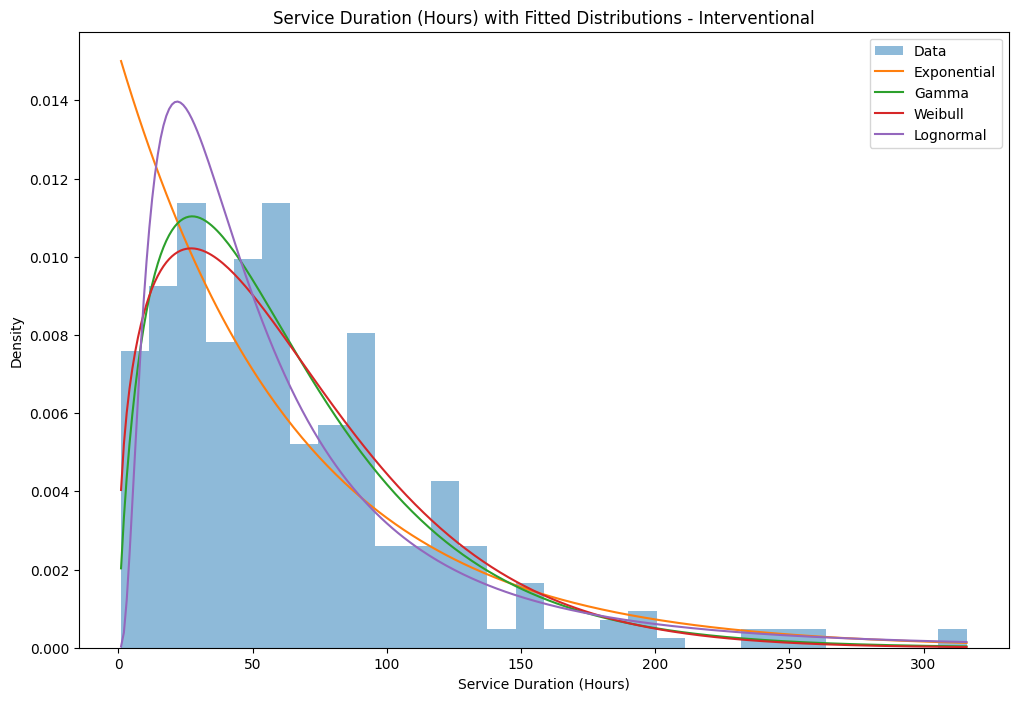

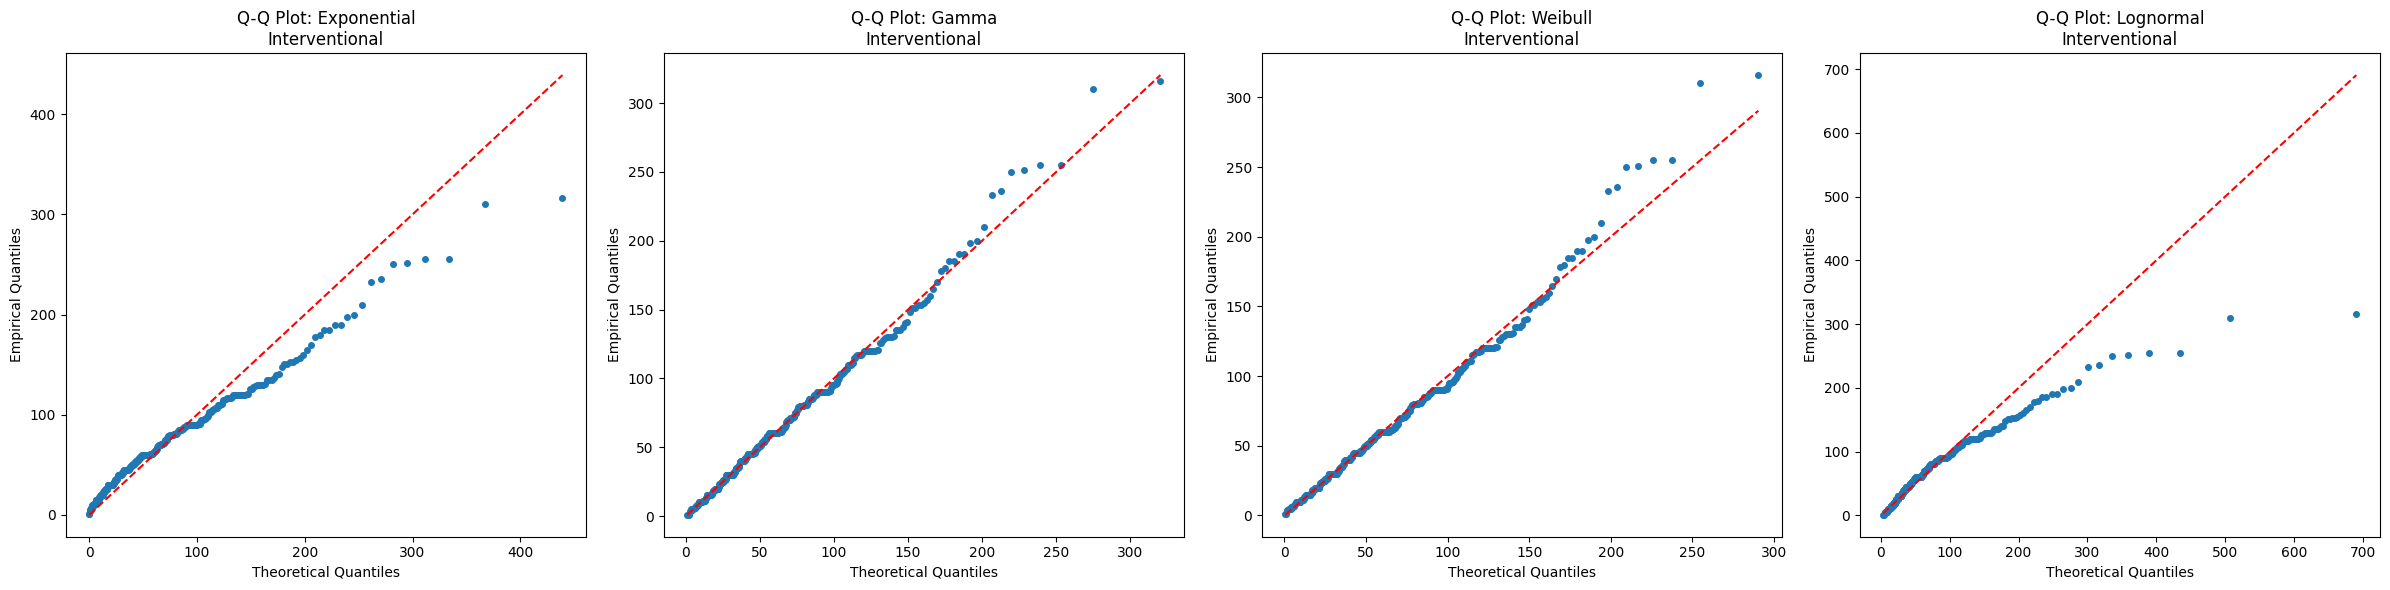

            group distribution      KS_D  KS_p_value        decision     n  \
1     Angiography        Gamma  0.032651    0.094942  Fail to reject  1419   
1  Interventional        Gamma  0.034201    0.721492  Fail to reject   402   

   mean_duration_hours  service_rate_per_hour param_1_name  param_1_value  \
1            52.546159               0.019031        shape       1.357691   
1            65.641791               0.015234        shape       1.720282   

  param_2_name  param_2_value param_3_name  param_3_value  
1          loc              0        scale      38.702579  
1          loc              0        scale      38.157573  


In [123]:
results_df, cleaned_df, outliers_df = fit_service_time_distribution(
    df=df_no_weekend,
    duration_col='LateTime_minutes',
    class_col='classification',
    max_hours=365,
    alpha=0.05,
    show_plots=True
)

print(results_df)

In [124]:
results_df

,group,distribution,KS_D,KS_p_value,decision,n,mean_duration_hours,service_rate_per_hour,param_1_name,param_1_value,param_2_name,param_2_value,param_3_name,param_3_value
1,Angiography,Gamma,0.032651,0.094942,Fail to reject,1419,52.546159,0.019031,shape,1.357691,loc,0,scale,38.702579
1,Interventional,Gamma,0.034201,0.721492,Fail to reject,402,65.641791,0.015234,shape,1.720282,loc,0,scale,38.157573
